# CA: Machine Learning Project — Spanish Wildfire Prediction (Binary Classification)

## Part 1: MODIS Fire Detection Data

### 1.1 Imports

In [ ]:
import os, gc, sys, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import regionmask
warnings.filterwarnings("ignore")

from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All imports OK.")
from sklearn.preprocessing import LabelEncoder
print("All imports OK.")

C:\Users\ealda\anaconda3\envs\fire_env2\lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


All imports OK.
All imports OK.


### 1.2 Paths

In [ ]:
base_path      = r"C:\Users\ealda\Downloads"
shapefile_path = r"C:\Users\ealda\Downloads\gadm41_ESP_shp\gadm41_ESP_2.shp"
ERA5_FILE      = r"C:\Users\ealda\Downloads\bea45c6f1bc0c7618fc8309e0efc90e4.nc"

### 1.3 Year Ranges

In [ ]:
training_years   = range(2003, 2023)
validation_years = range(2023, 2025)

### 1.4 Load FIRMS CSVs

In [ ]:
KEEP = ["acq_date", "latitude", "longitude", "confidence", "brightness"]

def load_year(year):
    path = os.path.join(base_path,
                        f"modis_{year}_all_countries",
                        "modis", str(year),
                        f"modis_{year}_Spain.csv")
    if not os.path.exists(path):
        print(f"  WARNING: not found — {path}")
        return None
    df = pd.read_csv(path, usecols=KEEP, parse_dates=["acq_date"])
    df["year"]  = df["acq_date"].dt.year
    df["month"] = df["acq_date"].dt.month
    return df.drop(columns=["acq_date"])

print("Loading training years...")
df_train = pd.concat([f for f in (load_year(y) for y in training_years)
                      if f is not None], ignore_index=True)
print(f"  {len(df_train):,} rows")

print("Loading validation years...")
df_val = pd.concat([f for f in (load_year(y) for y in validation_years)
                    if f is not None], ignore_index=True)
print(f"  {len(df_val):,} rows")

Loading training years...
  91,816 rows
Loading validation years...
  4,912 rows


### 1.5 Build Coordinate for Province Lookup

In [ ]:
print("Loading shapefile...")
provinces = (gpd.read_file(shapefile_path, encoding="utf-8")
               [["NAME_2", "geometry"]].to_crs("EPSG:4326"))

coords = pd.concat([df_train[["latitude","longitude"]],
                    df_val[["latitude","longitude"]]]).drop_duplicates()
print(f"Unique coordinate pairs: {len(coords):,}")

gdf = gpd.GeoDataFrame(coords,
        geometry=gpd.points_from_xy(coords["longitude"], coords["latitude"]),
        crs="EPSG:4326")
joined = gpd.sjoin(gdf, provinces, how="left", predicate="within")
lookup = (joined[["latitude","longitude","NAME_2"]]
          .rename(columns={"NAME_2":"province"})
          .drop_duplicates(subset=["latitude","longitude"]))

del gdf, joined, provinces, coords
gc.collect()
print(f"Lookup: {len(lookup):,} rows, {lookup['province'].isna().sum():,} unmatched")

Loading shapefile...
Unique coordinate pairs: 96,556
Lookup: 96,556 rows, 648 unmatched


### 1.6 Assign Provinces, Apply Confidence Filter, and Aggregate

In [ ]:
def assign_and_aggregate(df, lookup):
    df = df.merge(lookup, on=["latitude","longitude"], how="left")
    df = df[df["confidence"] >= 30]
    return (df.groupby(["year","month","province"])
              .size().reset_index(name="fire_count"))

df_train = assign_and_aggregate(df_train, lookup)
df_val   = assign_and_aggregate(df_val,   lookup)
gc.collect()

print(f"df_train: {df_train.shape}  {df_train.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"df_val:   {df_val.shape}    {df_val.memory_usage(deep=True).sum()/1e6:.1f} MB")
df_train.head()

df_train: (8031, 4)  0.7 MB
df_val:   (715, 4)    0.1 MB


,year,month,province,fire_count
0,2003,1,Albacete,25
1,2003,1,Alicante,1
2,2003,1,Almería,2
3,2003,1,Asturias,3
4,2003,1,Badajoz,2


### 1.7 EDA — Fire Counts by Year and Province

In [ ]:
by_year = df_train.groupby("year")["fire_count"].sum().reset_index()
by_year.columns = ["Year","Total Detections"]
print("=== Fire Detections by Year (2003–2022) ===")
print(by_year.to_string(index=False))
print()
by_prov = (df_train.groupby("province")["fire_count"]
           .sum().sort_values(ascending=False).head(15).reset_index())
by_prov.columns = ["Province","Total Detections"]
print("=== Top 15 Provinces ===")
print(by_prov.to_string(index=False))

=== Fire Detections by Year (2003–2022) ===
 Year  Total Detections
 2003              7146
 2004              7578
 2005              6598
 2006              6829
 2007              4216
 2008              2851
 2009              4394
 2010              2576
 2011              5150
 2012              5873
 2013              3292
 2014              2465
 2015              3024
 2016              3049
 2017              4914
 2018              1580
 2019              3147
 2020              2460
 2021              4419
 2022              5606

=== Top 15 Provinces ===
              Province  Total Detections
              Asturias              7514
               Ourense              7446
                  León              5120
               Sevilla              4741
               Badajoz              3976
              A Coruña              3690
            Pontevedra              3233
               Cáceres              3173
                Zamora              2674
              Va

### 1.8 EFFIS Validation and 2006 Outlier

In [ ]:
effis_ha = {
    2006:118368, 2007:56539,  2008:10073,  2009:88845, 2010:19770,
    2011:60060,  2012:189376, 2013:37069,  2014:22001, 2015:63560,
    2016:52644,  2017:130925, 2018:12433,  2019:63853, 2020:61099,
    2021:84827,  2022:306555,
}
modis = df_train.groupby("year")["fire_count"].sum().to_dict()
compare = pd.DataFrame({
    "modis_detections": pd.Series(modis),
    "effis_hectares":   pd.Series(effis_ha),
}).dropna().sort_index()

corr_all  = compare.corr().iloc[0,1]
corr_excl = compare.drop(index=2006, errors='ignore').corr().iloc[0,1]
print(f"Correlation all years (2006-2022):     {corr_all:.3f}")
print(f"Correlation excluding 2006 (2007-2022): {corr_excl:.3f}")
print()
print(compare.to_string())

Correlation all years (2006-2022):     0.721
Correlation excluding 2006 (2007-2022): 0.775

      modis_detections  effis_hectares
2006              6829        118368.0
2007              4216         56539.0
2008              2851         10073.0
2009              4394         88845.0
2010              2576         19770.0
2011              5150         60060.0
2012              5873        189376.0
2013              3292         37069.0
2014              2465         22001.0
2015              3024         63560.0
2016              3049         52644.0
2017              4914        130925.0
2018              1580         12433.0
2019              3147         63853.0
2020              2460         61099.0
2021              4419         84827.0
2022              5606        306555.0


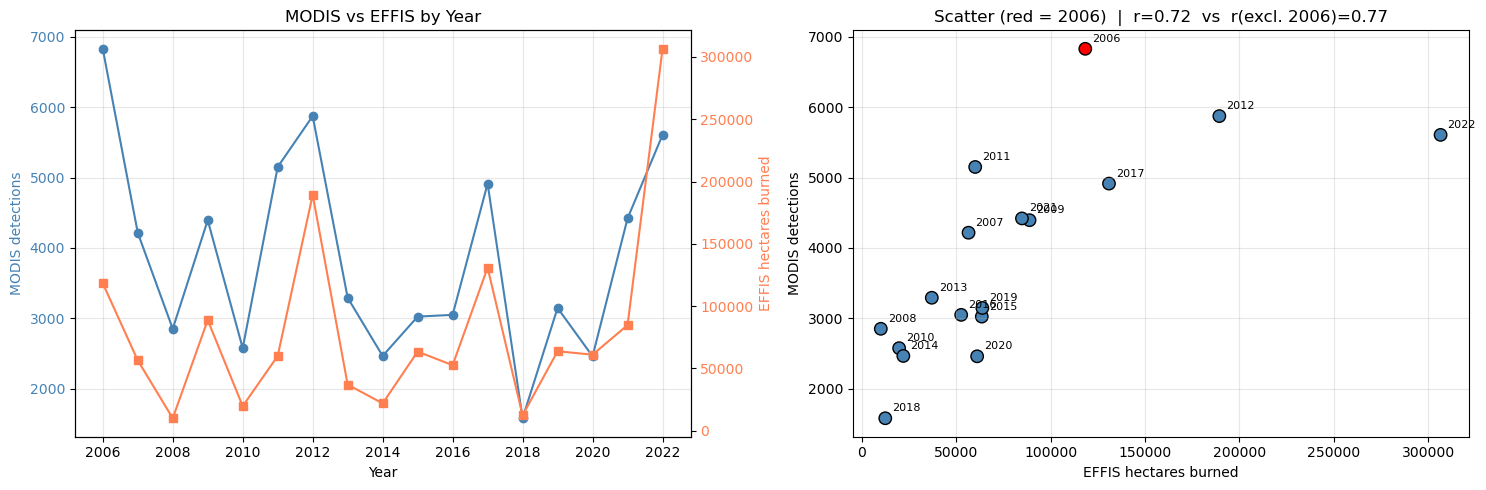

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(compare.index, compare['modis_detections'], color='steelblue', marker='o', label='MODIS detections')
ax2.plot(compare.index, compare['effis_hectares'],   color='coral',     marker='s', label='EFFIS hectares')
ax1.set_xlabel('Year')
ax1.set_ylabel('MODIS detections', color='steelblue')
ax2.set_ylabel('EFFIS hectares burned', color='coral')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='coral')
ax1.set_title('MODIS vs EFFIS by Year')
ax1.grid(True, alpha=0.3)

ax3 = axes[1]
colors = ['red' if y == 2006 else 'steelblue' for y in compare.index]
ax3.scatter(compare['effis_hectares'], compare['modis_detections'], c=colors, s=80, edgecolor='k')
for y, row in compare.iterrows():
    ax3.annotate(str(y), (row['effis_hectares'], row['modis_detections']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
ax3.set_xlabel('EFFIS hectares burned')
ax3.set_ylabel('MODIS detections')
ax3.set_title(f'Scatter (red = 2006)  |  r={corr_all:.2f}  vs  r(excl. 2006)={corr_excl:.2f}')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 2: ERA5-Land Climate Variables (2003–2024)

### 2.1 Install ERA5 Dependencies (run once, then restart kernel if needed)

In [ ]:
!{sys.executable} -m pip install xarray netCDF4 rioxarray regionmask --quiet
print("Done.")

Done.


### 2.2 Inspect ERA5 File

In [ ]:
ds = xr.open_dataset(ERA5_FILE)
lat_dim  = "latitude"   if "latitude"   in ds.dims else "lat"
lon_dim  = "longitude"  if "longitude"  in ds.dims else "lon"
time_dim = "valid_time" if "valid_time" in ds.dims else "time"
print(f"lat={lat_dim}, lon={lon_dim}, time={time_dim}")
print(f"Time steps: {len(ds[time_dim].values)}")
print(f"Variables:  {list(ds.data_vars)}")

lat=latitude, lon=longitude, time=valid_time
Time steps: 264
Variables:  ['d2m', 't2m', 'skt', 'stl1', 'src', 'swvl1', 'fal', 'ssr', 'str', 'pev', 'e', 'u10', 'v10', 'tp', 'lai_hv', 'lai_lv']


### 2.3 Load Province Boundaries for ERA5

In [ ]:
provinces_era5 = (gpd.read_file(shapefile_path, encoding="utf-8")
                    [["NAME_2","geometry"]].to_crs("EPSG:4326")
                    .rename(columns={"NAME_2":"province"})
                    .reset_index(drop=True))
print(f"Provinces: {len(provinces_era5)}")

Provinces: 52


### 2.4 Aggregate ERA5 to Province Level

In [ ]:
print("Building province mask...")
mask = regionmask.mask_geopandas(
    provinces_era5, ds[lon_dim].values, ds[lat_dim].values)

times = pd.DatetimeIndex(ds[time_dim].values)
n_t, n_p = len(times), len(provinces_era5)

# Load ALL variables present in the file
ALL_ERA5_VARS = list(ds.data_vars)
print(f"Variables in file: {ALL_ERA5_VARS}")

results = {}
for v in ALL_ERA5_VARS:
    print(f"  {v}...")
    da = ds[v].values
    arr = np.full((n_t, n_p), np.nan, dtype=np.float32)
    for p in range(n_p):
        pm = (mask.values == p)
        if pm.any():
            arr[:, p] = np.nanmean(da[:, pm], axis=1)
    results[v] = arr
ds.close()
print("Done.")

Building province mask...
Variables in file: ['d2m', 't2m', 'skt', 'stl1', 'src', 'swvl1', 'fal', 'ssr', 'str', 'pev', 'e', 'u10', 'v10', 'tp', 'lai_hv', 'lai_lv']
  d2m...
  t2m...
  skt...
  stl1...
  src...
  swvl1...
  fal...
  ssr...
  str...
  pev...
  e...
  u10...
  v10...
  tp...
  lai_hv...
  lai_lv...
Done.


In [ ]:
precip_mm   = results["tp"]    * 1000
t2m_c       = results["t2m"]  - 273.15
td2m_c      = results["d2m"]  - 273.15
solar_mj    = results["ssr"]  / 1e6
pot_evap_mm = results["pev"]  * 1000
u10, v10    = results["u10"],  results["v10"]
swvl1       = results["swvl1"]
wind_speed  = np.sqrt(u10**2 + v10**2)
rh          = (100 * np.exp((17.625*td2m_c)/(243.04+td2m_c)) /
                    np.exp((17.625*t2m_c)/(243.04+t2m_c))).astype(np.float32)
precip_def  = np.abs(pot_evap_mm) - precip_mm

# Extra variables
# skt: skin temperature (°C)
skt_c    = results["skt"]   - 273.15   if "skt"   in results else None
# stl1: soil temperature layer 1 (°C)
stl1_c   = results["stl1"]  - 273.15   if "stl1"  in results else None
# e: evaporation (mm, negative in ERA5 = upward flux)
evap_mm  = results["e"]     * 1000     if "e"     in results else None
# lai_hv, lai_lv: leaf area index high/low vegetation (m²)
lai_hv   = results["lai_hv"]           if "lai_hv" in results else None
lai_lv   = results["lai_lv"]           if "lai_lv" in results else None
# fal: albedo (0-1)
fal      = results["fal"]              if "fal"   in results else None
# str: surface thermal radiation (MJ/m²)
str_mj   = results["str"]   / 1e6     if "str"   in results else None
# src: skin reservoir content (mm)
src_mm   = results["src"]   * 1000    if "src"   in results else None

prov_names = np.tile(provinces_era5["province"].values, n_t)
years      = np.repeat([t.year  for t in times], n_p)
months     = np.repeat([t.month for t in times], n_p)

era5_dict = {
    "province":              prov_names,
    "year":                  years,
    "month":                 months,
    "precip_mm":             precip_mm.ravel().round(2),
    "temp_c":                t2m_c.ravel().round(2),
    "dewpoint_c":            td2m_c.ravel().round(2),
    "wind_u_ms":             u10.ravel().round(3),
    "wind_v_ms":             v10.ravel().round(3),
    "wind_speed_ms":         wind_speed.ravel().round(3),
    "soil_moisture":         swvl1.ravel().round(4),
    "solar_radiation_mj":    solar_mj.ravel().round(2),
    "pot_evap_mm":           pot_evap_mm.ravel().round(2),
    "relative_humidity_pct": rh.ravel().round(1),
    "precip_deficit_mm":     precip_def.ravel().round(2),
}

if skt_c  is not None: era5_dict["skt_c"]   = skt_c.ravel().round(2)
if stl1_c is not None: era5_dict["stl1_c"]  = stl1_c.ravel().round(2)
if evap_mm is not None: era5_dict["evap_mm"] = evap_mm.ravel().round(2)
if lai_hv  is not None: era5_dict["lai_hv"]  = lai_hv.ravel().round(4)
if lai_lv  is not None: era5_dict["lai_lv"]  = lai_lv.ravel().round(4)
if fal     is not None: era5_dict["fal"]     = fal.ravel().round(4)
if str_mj  is not None: era5_dict["str_mj"]  = str_mj.ravel().round(2)
if src_mm  is not None: era5_dict["src_mm"]  = src_mm.ravel().round(2)

df_era5 = pd.DataFrame(era5_dict).sort_values(["province","year","month"]).reset_index(drop=True)
print(f"ERA5 shape: {df_era5.shape}, years: {df_era5['year'].min()}–{df_era5['year'].max()}")
print(f"Columns: {list(df_era5.columns)}")
df_era5.head()

ERA5 shape: (13728, 22), years: 2003–2024
Columns: ['province', 'year', 'month', 'precip_mm', 'temp_c', 'dewpoint_c', 'wind_u_ms', 'wind_v_ms', 'wind_speed_ms', 'soil_moisture', 'solar_radiation_mj', 'pot_evap_mm', 'relative_humidity_pct', 'precip_deficit_mm', 'skt_c', 'stl1_c', 'evap_mm', 'lai_hv', 'lai_lv', 'fal', 'str_mj', 'src_mm']


,province,year,month,precip_mm,temp_c,dewpoint_c,wind_u_ms,wind_v_ms,wind_speed_ms,soil_moisture,...,relative_humidity_pct,precip_deficit_mm,skt_c,stl1_c,evap_mm,lai_hv,lai_lv,fal,str_mj,src_mm
0,A Coruña,2003,1,7.63,7.33,4.84,0.751,0.243,0.789,0.4044,...,84.199997,-5.70,6.61,7.31,-1.32,1.6018,2.8098,0.1266,-4.28,0.20
1,A Coruña,2003,2,3.29,7.88,5.19,0.048,1.053,1.054,0.3879,...,83.099998,-1.31,7.41,7.77,-1.32,1.6017,2.8132,0.1308,-3.77,0.16
2,A Coruña,2003,3,3.01,11.02,8.01,-0.346,0.986,1.045,0.3759,...,81.699997,0.09,10.94,11.23,-2.14,1.6149,3.0122,0.1363,-5.07,0.14
3,A Coruña,2003,4,4.89,11.53,8.04,-0.201,1.287,1.303,0.3796,...,79.099998,-0.26,11.78,12.24,-3.08,1.6504,3.3885,0.1423,-4.91,0.16
4,A Coruña,2003,5,1.38,13.28,9.68,0.018,-1.104,1.104,0.3197,...,78.800003,4.34,14.24,14.60,-3.86,1.6863,3.7216,0.1469,-5.92,0.07


## Part 3: Build Modelling Dataset

### 3.1 Merge MODIS Fire Counts with ERA5

In [ ]:
era5_train = df_era5[df_era5["year"] <= 2022].copy()
era5_val   = df_era5[df_era5["year"] >= 2023].copy()

df_m_train = era5_train.merge(
    df_train[["year","month","province","fire_count"]],
    on=["year","month","province"], how="left")
df_m_val = era5_val.merge(
    df_val[["year","month","province","fire_count"]],
    on=["year","month","province"], how="left")

df_m_train["fire_count"] = df_m_train["fire_count"].fillna(0).astype(int)
df_m_val["fire_count"]   = df_m_val["fire_count"].fillna(0).astype(int)

df_m_train = df_m_train[df_m_train["year"] >= 2007].reset_index(drop=True)

print(f"Training:   {df_m_train.shape}  ({df_m_train['year'].min()}–{df_m_train['year'].max()})")
print(f"Validation: {df_m_val.shape}  ({df_m_val['year'].min()}–{df_m_val['year'].max()})")
print(f"\nERA5 columns available: {[c for c in df_m_train.columns if c not in ['year','month','province','fire_count']]}")

Training:   (9984, 23)  (2007–2022)
Validation: (1248, 23)  (2023–2024)

ERA5 columns available: ['precip_mm', 'temp_c', 'dewpoint_c', 'wind_u_ms', 'wind_v_ms', 'wind_speed_ms', 'soil_moisture', 'solar_radiation_mj', 'pot_evap_mm', 'relative_humidity_pct', 'precip_deficit_mm', 'skt_c', 'stl1_c', 'evap_mm', 'lai_hv', 'lai_lv', 'fal', 'str_mj', 'src_mm']


### 3.2 Target Distribution (fire_count) and Log Feature

In [ ]:
print("=== Target distribution (fire_count) ===")
print(df_m_train["fire_count"].describe().round(2))
print(f"% zero months: {100*(df_m_train['fire_count']==0).mean():.1f}%")
print(f"% months > 50: {100*(df_m_train['fire_count']>50).mean():.1f}%")
print(f"Max:           {df_m_train['fire_count'].max()}")

# Apply log transform
df_m_train["fire_log"] = np.log1p(df_m_train["fire_count"])
df_m_val["fire_log"]   = np.log1p(df_m_val["fire_count"])

print("\n=== After log(1+x) transform ===")
print(df_m_train["fire_log"].describe().round(3))

=== Target distribution (fire_count) ===
count    9984.00
mean        5.91
std        23.50
min         0.00
25%         0.00
50%         1.00
75%         5.00
max      1080.00
Name: fire_count, dtype: float64
% zero months: 37.3%
% months > 50: 1.7%
Max:           1080

=== After log(1+x) transform ===
count    9984.000
mean        1.062
std         1.100
min         0.000
25%         0.000
50%         0.693
75%         1.792
max         6.986
Name: fire_log, dtype: float64


### 3.3 Feature Engineering

In [19]:
NO_LAG = {"wind_u_ms","wind_v_ms","fal","src_mm"}
LAG_VARS = [c for c in df_era5.columns
            if c not in {"province","year","month"} and c not in NO_LAG]

df_all = pd.concat([df_m_train, df_m_val], ignore_index=True)
df_all = df_all.sort_values(["province","year","month"]).reset_index(drop=True)

df_all["month_sin"] = np.sin(2 * np.pi * df_all["month"] / 12)
df_all["month_cos"] = np.cos(2 * np.pi * df_all["month"] / 12)

df_all["province_enc"] = LabelEncoder().fit_transform(df_all["province"])

def saturation_vp(t_c):
    return 6.112 * np.exp((17.625 * t_c) / (243.04 + t_c))
es_t  = saturation_vp(df_all["temp_c"])
es_td = saturation_vp(df_all["dewpoint_c"])
df_all["vpd_kpa"] = (es_t - es_td) / 10.0   # hPa -> kPa

df_all["fuel_dryness"] = (df_all["temp_c"] * (100 - df_all["relative_humidity_pct"]) /
                          (df_all["soil_moisture"] + 0.01))

df_all["wind_x_dryness"] = df_all["wind_speed_ms"] * (100 - df_all["relative_humidity_pct"])

for var in LAG_VARS:
    if var in df_all.columns:
        df_all[f"{var}_lag1"]  = df_all.groupby("province")[var].shift(1)
        df_all[f"{var}_roll3"] = (df_all.groupby("province")[var]
                                   .transform(lambda x: x.shift(1).rolling(3).mean()))

EXTENDED_LAG_VARS = ["precip_mm","soil_moisture","lai_hv","lai_lv","evap_mm",
                     "relative_humidity_pct","precip_deficit_mm"]
EXTENDED_LAG_VARS = [v for v in EXTENDED_LAG_VARS if v in df_all.columns]
for var in EXTENDED_LAG_VARS:
    df_all[f"{var}_roll6"] = (df_all.groupby("province")[var]
                               .transform(lambda x: x.shift(1).rolling(6).mean()))

for w in [3, 6]:
    df_all[f"precip_cum{w}m"] = (df_all.groupby("province")["precip_mm"]
                                  .transform(lambda x: x.shift(1).rolling(w).sum()))

if "evap_mm_roll6" in df_all.columns and "precip_cum6m" in df_all.columns:
    df_all["drought_index"] = df_all["precip_cum6m"] + df_all["evap_mm_roll6"] * 6

if "lai_hv_roll3" in df_all.columns:
    df_all["vegetation_stress"] = df_all["lai_hv_roll3"] * df_all["precip_deficit_mm"]

df_all["fire_log_lag1"] = df_all.groupby("province")["fire_log"].shift(1)

df_m_train = df_all[df_all["year"] <= 2022].dropna().reset_index(drop=True)
df_m_val   = df_all[df_all["year"] >= 2023].dropna().reset_index(drop=True)

df_m_train["fire_binary"] = (df_m_train["fire_count"] > 0).astype(int)
df_m_val["fire_binary"]   = (df_m_val["fire_count"] > 0).astype(int)

combo_features = ["vpd_kpa","fuel_dryness","wind_x_dryness","drought_index","vegetation_stress"]
combo_features = [c for c in combo_features if c in df_all.columns]
print(f"After feature engineering — train: {df_m_train.shape}, val: {df_m_val.shape}")
print(f"Combination features added: {combo_features}")
print(f"Extended lag vars: {EXTENDED_LAG_VARS}")
print(f"Binary fire rate (train): {df_m_train['fire_binary'].mean():.1%}")

NameError: name 'df_era5' is not defined

### 3.4 Define Binary Target

In [ ]:
df_m_train['fire_binary'] = (df_m_train['fire_count'] > 0).astype(int)
df_m_val['fire_binary']   = (df_m_val['fire_count']   > 0).astype(int)

print('Binary fire rate (training 2007-2022):  ', round(df_m_train['fire_binary'].mean()*100, 2), '%')
print('Binary fire rate (validation 2023-2024):', round(df_m_val['fire_binary'].mean()*100, 2), '%')

Binary fire rate (training 2007-2022):   65.04 %
Binary fire rate (validation 2023-2024): 59.58 %


### 3.5 Feature Selection (Dropping dupplicates)

In [ ]:
SKIP_COLS = {'province','year','month','fire_count','fire_log','fire_binary'}
ALL_FEATURES = [c for c in df_m_train.columns
                if c not in SKIP_COLS
                and df_m_train[c].dtype in (np.float32, np.float64, np.int32, np.int64)]

DROP_DUPLICATES = ['dewpoint_c','wind_u_ms','wind_v_ms','pot_evap_mm','solar_radiation_mj']
FEATURES_FINAL = [f for f in ALL_FEATURES if f not in DROP_DUPLICATES]

print(f'Features at start:                 {len(ALL_FEATURES)}')
print(f'Dropped as duplicates:             {DROP_DUPLICATES}')
print(f'Features remaining for modelling:  {len(FEATURES_FINAL)}')

Features at start:                 67
Dropped as duplicates:             ['dewpoint_c', 'wind_u_ms', 'wind_v_ms', 'pot_evap_mm', 'solar_radiation_mj']
Features remaining for modelling:  62


### 3.6 Correlation Diagnostic (For Reference Only)

In [ ]:
corr = df_m_train[FEATURES_FINAL].corr().abs()
THRESHOLD = 0.85

pairs = []
cols = corr.columns.tolist()
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        v = corr.iloc[i,j]
        if v >= THRESHOLD:
            pairs.append((cols[i], cols[j], round(v,3)))

pairs_df = (pd.DataFrame(pairs, columns=['Feature A','Feature B','|r|'])
              .sort_values('|r|', ascending=False))
print(f'Highly correlated pairs (|r| >= {THRESHOLD})  [{len(pairs_df)} found]:')
print(pairs_df.head(15).to_string(index=False))

Highly correlated pairs (|r| >= 0.85)  [73 found]:
      Feature A    Feature B   |r|
precip_mm_roll3 precip_cum3m 1.000
precip_mm_roll6 precip_cum6m 1.000
     skt_c_lag1  stl1_c_lag1 0.999
          skt_c       stl1_c 0.999
    skt_c_roll3 stl1_c_roll3 0.999
   temp_c_roll3  skt_c_roll3 0.997
   temp_c_roll3 stl1_c_roll3 0.997
         temp_c       stl1_c 0.996
         temp_c        skt_c 0.996
    temp_c_lag1  stl1_c_lag1 0.996
    temp_c_lag1   skt_c_lag1 0.996
    lai_lv_lag1 lai_lv_roll3 0.985
         lai_lv  lai_lv_lag1 0.983
    lai_hv_lag1 lai_hv_roll3 0.982
         lai_hv  lai_hv_lag1 0.980


### 3.7 Prepare Train/Validation Arrays and DataFrames

In [ ]:
df_m_train = df_m_train.dropna(subset=FEATURES_FINAL).reset_index(drop=True)
df_m_val   = df_m_val.dropna(subset=FEATURES_FINAL).reset_index(drop=True)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

df = df_m_train.copy()
df_val = df_m_val.copy()

print('Training shape:  ', df.shape)
print('Validation shape:', df_val.shape)
df.head()

Training shape:   (9300, 73)
Validation shape: (1200, 73)


,province,year,month,precip_mm,temp_c,dewpoint_c,wind_u_ms,wind_v_ms,wind_speed_ms,soil_moisture,...,lai_lv_roll6,evap_mm_roll6,relative_humidity_pct_roll6,precip_deficit_mm_roll6,precip_cum3m,precip_cum6m,drought_index,vegetation_stress,fire_log_lag1,fire_binary
0,A Coruña,2007,7,2.02,16.719999,13.77,0.997,-0.246,1.027,0.2896,...,3.272550,-2.565000,82.716666,-0.191667,9.41,24.17,8.78,6.104571,0.000000,0
1,A Coruña,2007,8,1.01,17.540001,13.59,-1.227,-2.392,2.689,0.1948,...,3.463083,-3.048333,82.149999,0.530000,9.54,23.82,5.53,9.129867,0.000000,0
2,A Coruña,2007,9,0.58,17.010000,11.87,-2.599,-1.622,3.063,0.1343,...,3.616883,-3.320000,81.083332,2.368333,7.36,16.72,-3.20,9.727556,0.000000,1
3,A Coruña,2007,10,0.41,14.330000,10.89,-1.329,-0.918,1.615,0.1790,...,3.699350,-3.308333,79.516665,3.436667,3.61,13.02,-6.83,4.892770,3.135494,1
4,A Coruña,2007,11,1.84,10.050000,6.45,-1.809,-0.582,1.901,0.2199,...,3.645950,-3.028333,79.383333,3.480000,2.00,11.54,-6.63,0.933837,1.945910,1


# Part 4 – Exploration of Data

### 4.1 Target Variable Distribution

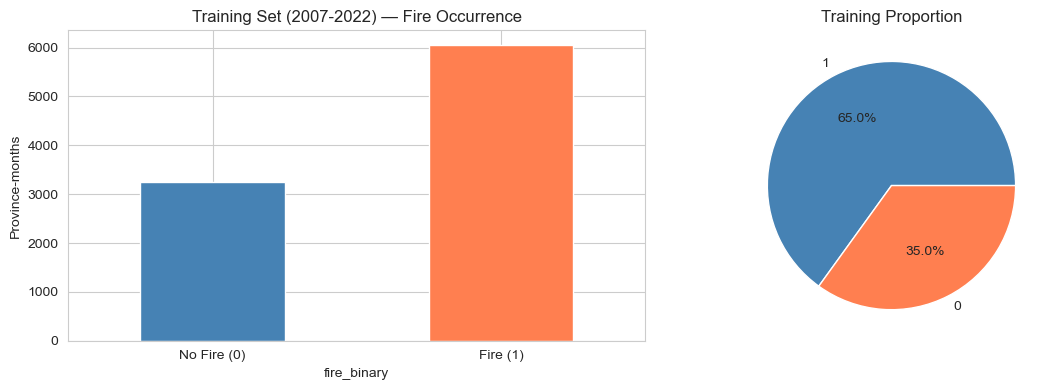

Training fire rate:   65.04 %
Validation fire rate: 59.58 %


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['fire_binary'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Training Set (2007-2022) — Fire Occurrence')
axes[0].set_xticklabels(['No Fire (0)', 'Fire (1)'], rotation=0)
axes[0].set_ylabel('Province-months')

df['fire_binary'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['steelblue', 'coral'])
axes[1].set_title('Training Proportion')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('Training fire rate:  ', round(df['fire_binary'].mean() * 100, 2), '%')
print('Validation fire rate:', round(df_val['fire_binary'].mean() * 100, 2), '%')

### 4.2 Fire Rate by Month and Year

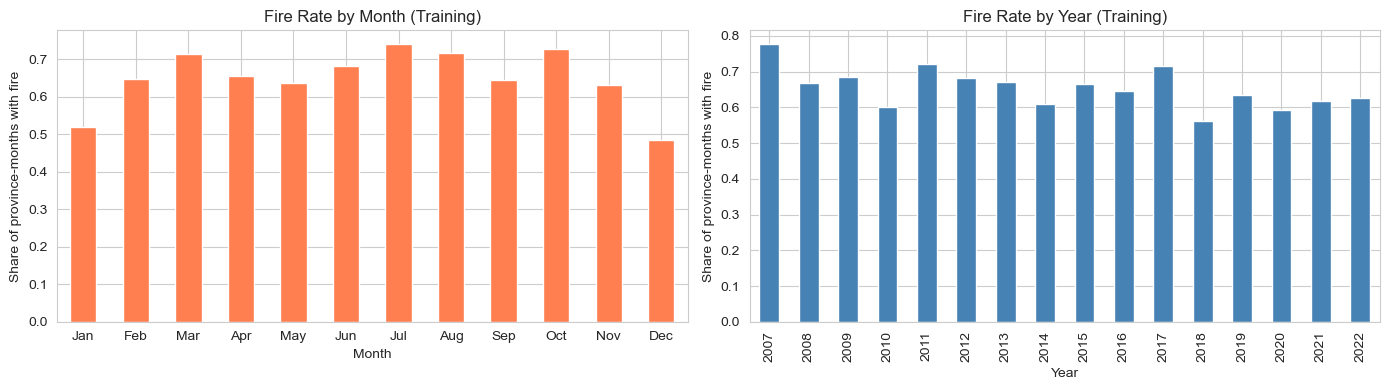

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby('month')['fire_binary'].mean().plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Fire Rate by Month (Training)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Share of province-months with fire')
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)

df.groupby('year')['fire_binary'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Fire Rate by Year (Training)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Share of province-months with fire')

plt.tight_layout()
plt.show()

### 4.3 Fire Rate by Province

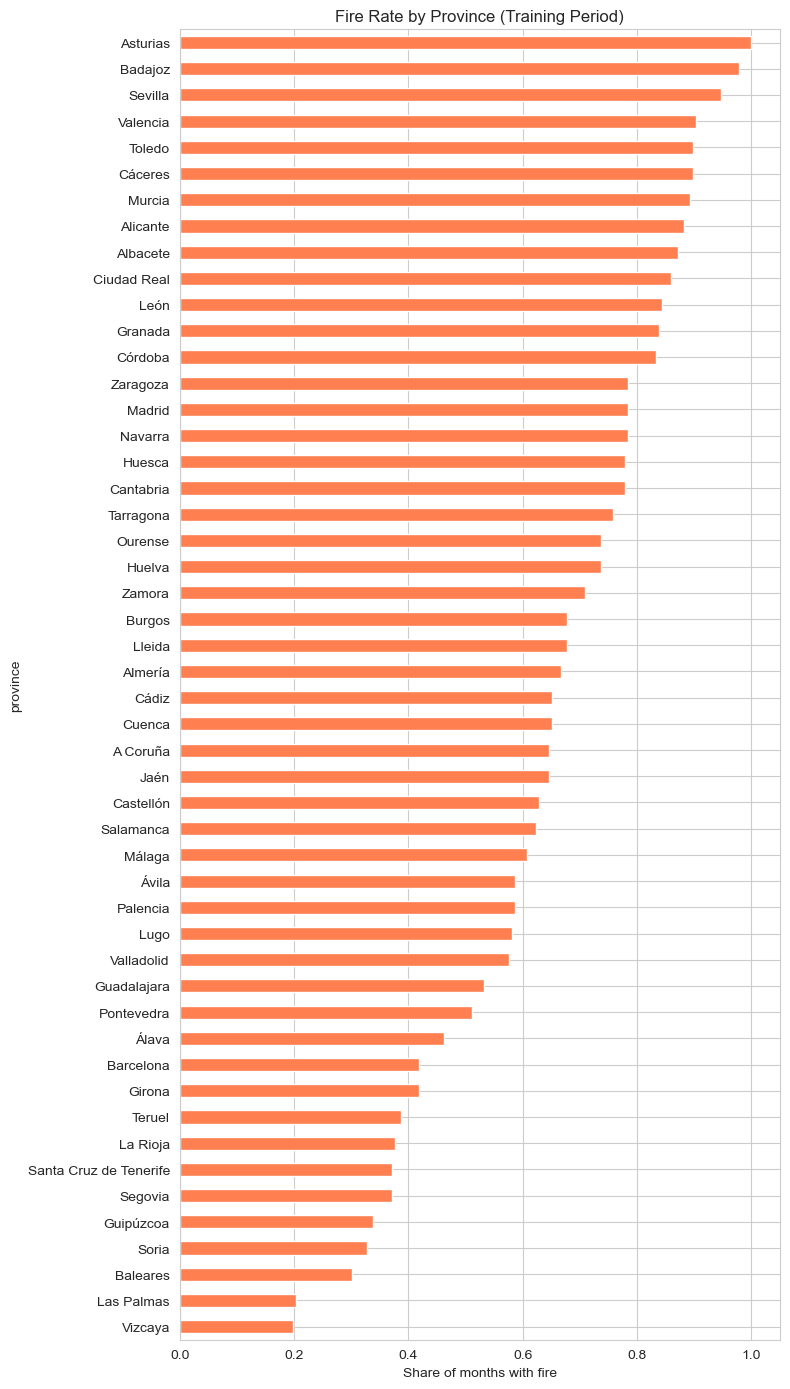

Top 5 most fire-prone provinces:
province
Toledo      0.898
Valencia    0.903
Sevilla     0.946
Badajoz     0.978
Asturias    1.000
Name: fire_binary, dtype: float64

Top 5 least fire-prone provinces:
province
Vizcaya       0.199
Las Palmas    0.204
Baleares      0.301
Soria         0.328
Guipúzcoa     0.339
Name: fire_binary, dtype: float64


In [ ]:
prov_fire = df.groupby('province')['fire_binary'].mean().sort_values(ascending=True)

plt.figure(figsize=(8, 14))
prov_fire.plot(kind='barh', color='coral')
plt.title('Fire Rate by Province (Training Period)')
plt.xlabel('Share of months with fire')
plt.tight_layout()
plt.show()

print('Top 5 most fire-prone provinces:')
print(prov_fire.tail(5).round(3))
print()
print('Top 5 least fire-prone provinces:')
print(prov_fire.head(5).round(3))

### 4.4 Climate Variables by Fire Status

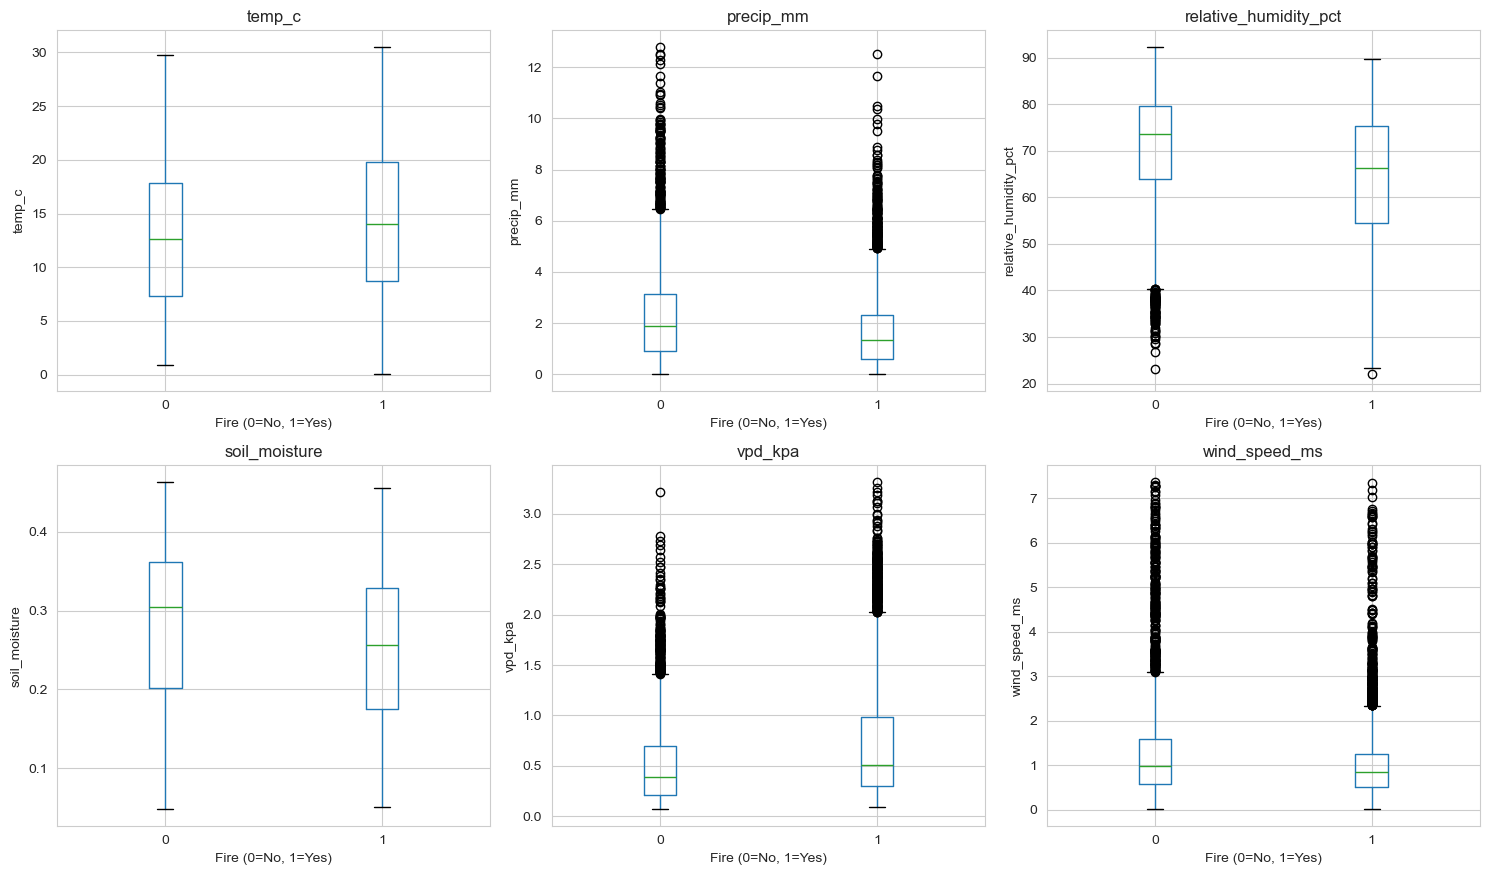

In [ ]:
key_vars = ['temp_c', 'precip_mm', 'relative_humidity_pct', 'soil_moisture', 'vpd_kpa', 'wind_speed_ms']
key_vars = [v for v in key_vars if v in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, var in enumerate(key_vars):
    ax = axes[i // 3, i % 3]
    df.boxplot(column=var, by='fire_binary', ax=ax)
    ax.set_title(var)
    ax.set_xlabel('Fire (0=No, 1=Yes)')
    ax.set_ylabel(var)

plt.suptitle('')
plt.tight_layout()
plt.show()

# Part 5 – Feature Selection (ML Workflow)

### 5.1 Define Target and Predictor Variables

In [ ]:
target = 'fire_binary'
features = [f for f in FEATURES_FINAL if f != 'fire_log_lag1']

print('Target:', target)
print('Number of features:', len(features))
print('Features:', features)

Target: fire_binary
Number of features: 61
Features: ['precip_mm', 'temp_c', 'wind_speed_ms', 'soil_moisture', 'relative_humidity_pct', 'precip_deficit_mm', 'skt_c', 'stl1_c', 'evap_mm', 'lai_hv', 'lai_lv', 'fal', 'str_mj', 'src_mm', 'month_sin', 'month_cos', 'province_enc', 'vpd_kpa', 'fuel_dryness', 'wind_x_dryness', 'precip_mm_lag1', 'precip_mm_roll3', 'temp_c_lag1', 'temp_c_roll3', 'dewpoint_c_lag1', 'dewpoint_c_roll3', 'wind_speed_ms_lag1', 'wind_speed_ms_roll3', 'soil_moisture_lag1', 'soil_moisture_roll3', 'solar_radiation_mj_lag1', 'solar_radiation_mj_roll3', 'pot_evap_mm_lag1', 'pot_evap_mm_roll3', 'relative_humidity_pct_lag1', 'relative_humidity_pct_roll3', 'precip_deficit_mm_lag1', 'precip_deficit_mm_roll3', 'skt_c_lag1', 'skt_c_roll3', 'stl1_c_lag1', 'stl1_c_roll3', 'evap_mm_lag1', 'evap_mm_roll3', 'lai_hv_lag1', 'lai_hv_roll3', 'lai_lv_lag1', 'lai_lv_roll3', 'str_mj_lag1', 'str_mj_roll3', 'precip_mm_roll6', 'soil_moisture_roll6', 'lai_hv_roll6', 'lai_lv_roll6', 'evap_mm_rol

### 5.2 Correlation with Target

Correlation with fire_binary:
vpd_kpa                       0.174471
fal                           0.143426
fuel_dryness                  0.130449
solar_radiation_mj_lag1       0.116929
temp_c                        0.116586
                                ...   
relative_humidity_pct_lag1   -0.175177
precip_mm                    -0.189233
src_mm                       -0.202328
str_mj                       -0.223329
relative_humidity_pct        -0.225213
Name: fire_binary, Length: 61, dtype: float64


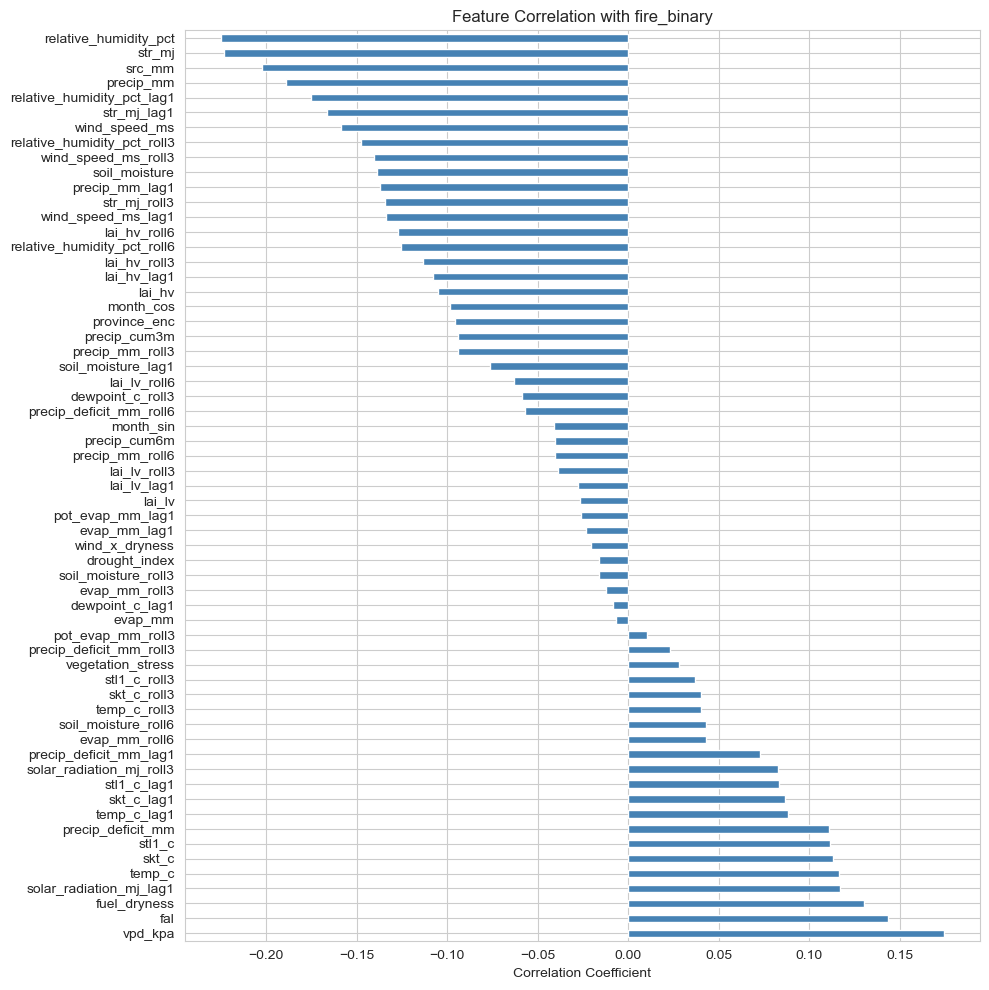

In [ ]:
target_corr = df[features + [target]].corr()[target].drop(target).sort_values(ascending=False)
print('Correlation with fire_binary:')
print(target_corr)

plt.figure(figsize=(10, 10))
target_corr.plot(kind='barh', color='steelblue')
plt.title('Feature Correlation with fire_binary')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

### 5.3 SelectKBest

Top 15 features by f_classif score:
relative_humidity_pct          496.799051
str_mj                         488.089245
src_mm                         396.875873
precip_mm                      345.320559
relative_humidity_pct_lag1     294.359689
vpd_kpa                        291.918817
str_mj_lag1                    265.490467
wind_speed_ms                  240.174233
relative_humidity_pct_roll3    207.879775
fal                            195.286519
wind_speed_ms_roll3            187.914778
soil_moisture                  182.743910
precip_mm_lag1                 177.790144
str_mj_roll3                   171.493244
wind_speed_ms_lag1             170.307051
dtype: float64


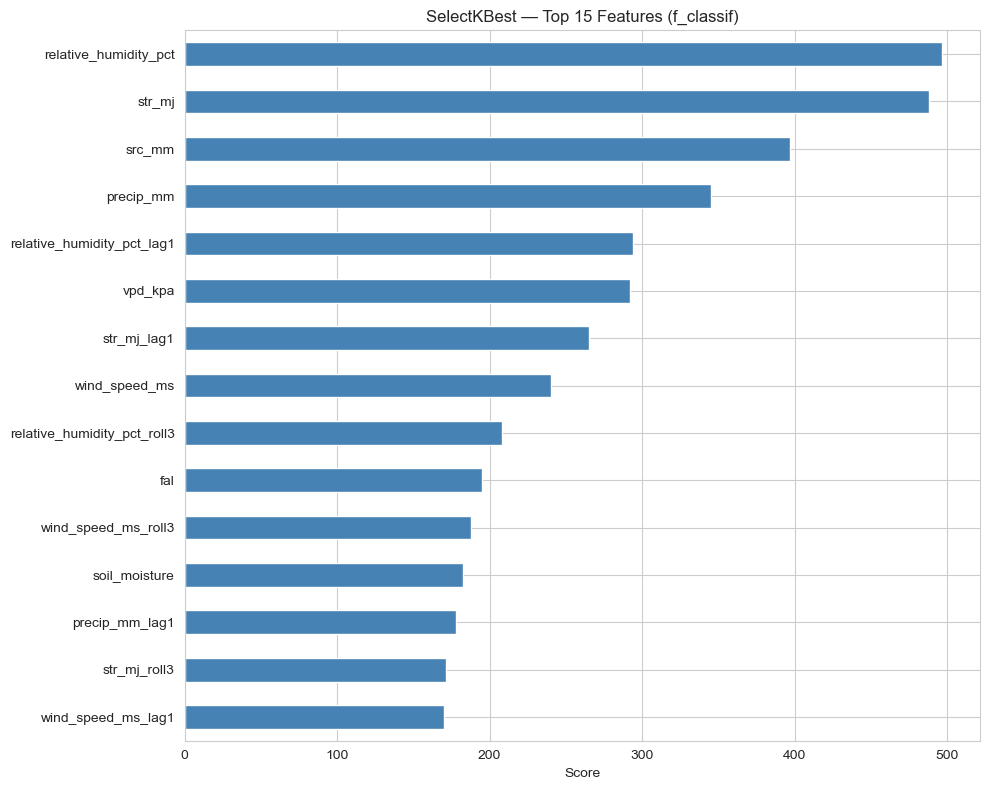

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

X = df[features]
y = df[target]

selector = SelectKBest(score_func=f_classif, k=min(15, len(features)))
selector.fit(X, y)

scores = pd.Series(selector.scores_, index=features).sort_values(ascending=False)
print('Top 15 features by f_classif score:')
print(scores.head(15))

plt.figure(figsize=(10, 8))
scores.head(15).plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('SelectKBest — Top 15 Features (f_classif)')
plt.xlabel('Score')
plt.tight_layout()
plt.show()

### 5.4 Recursive Feature Elimination (RFE)

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

lr_rfe = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=lr_rfe, n_features_to_select=10)
rfe.fit(X, y)

rfe_ranking = pd.Series(rfe.ranking_, index=features).sort_values()
print('RFE feature ranking (1 = selected):')
print(rfe_ranking.head(20))

rfe_selected = rfe_ranking[rfe_ranking == 1].index.tolist()
print()
print('RFE selected features:', rfe_selected)

RFE feature ranking (1 = selected):
temp_c                  1
stl1_c                  1
fal                     1
evap_mm                 1
soil_moisture_roll3     1
lai_lv_lag1             1
lai_hv_roll3            1
lai_lv_roll3            1
soil_moisture_roll6     1
lai_lv_roll6            1
month_cos               2
lai_hv                  3
str_mj                  4
evap_mm_lag1            5
temp_c_roll3            6
month_sin               7
skt_c_roll3             8
soil_moisture_lag1      9
dewpoint_c_lag1        10
soil_moisture          11
dtype: int64

RFE selected features: ['temp_c', 'stl1_c', 'fal', 'evap_mm', 'soil_moisture_roll3', 'lai_lv_lag1', 'lai_hv_roll3', 'lai_lv_roll3', 'soil_moisture_roll6', 'lai_lv_roll6']


### 5.5 Feature Importance — Decision Tree

Top 15 Decision Tree feature importances:
fal                            0.296760
province_enc                   0.197714
str_mj                         0.170602
wind_speed_ms                  0.067033
evap_mm                        0.049406
lai_lv                         0.047075
soil_moisture_roll6            0.038125
relative_humidity_pct          0.026062
relative_humidity_pct_roll6    0.019959
solar_radiation_mj_roll3       0.018897
lai_hv                         0.016465
lai_lv_roll3                   0.015166
dewpoint_c_roll3               0.011039
precip_deficit_mm_roll6        0.009086
evap_mm_roll3                  0.004453
dtype: float64


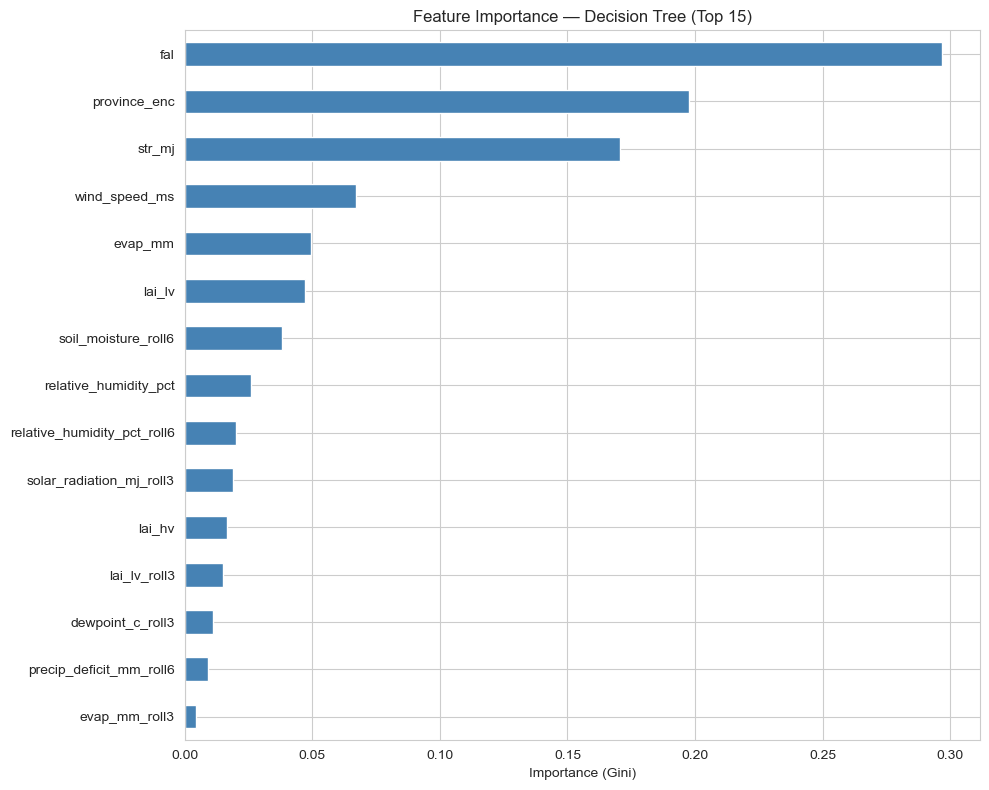

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_fi = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_fi.fit(X, y)

importances = pd.Series(dt_fi.feature_importances_, index=features).sort_values(ascending=False)
print('Top 15 Decision Tree feature importances:')
print(importances.head(15))

plt.figure(figsize=(10, 8))
importances.head(15).plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Feature Importance — Decision Tree (Top 15)')
plt.xlabel('Importance (Gini)')
plt.tight_layout()
plt.show()

### 5.6 Feature Scaling and Train/Test Split

In [ ]:
from sklearn.preprocessing import StandardScaler

X_train = df[features]
y_train = df[target]
X_test = df_val[features]
y_test = df_val[target]

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=features, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=features, index=X_test.index)

print('Training set:', X_train.shape)
print('Test set:    ', X_test.shape)
print('Training fire rate:', round(y_train.mean() * 100, 2), '%')
print('Test fire rate:    ', round(y_test.mean() * 100, 2), '%')

Training set: (9300, 61)
Test set:     (1200, 61)
Training fire rate: 65.04 %
Test fire rate:     59.58 %


# Part 6 – Model Development

### 6.1 Logistic Regression

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print('Logistic Regression Results (with balanced class weights):')
print(classification_report(y_test, y_pred_lr))
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob_lr), 4))

Logistic Regression Results (with balanced class weights):
              precision    recall  f1-score   support

           0       0.58      0.41      0.48       485
           1       0.67      0.80      0.73       715

    accuracy                           0.64      1200
   macro avg       0.63      0.61      0.60      1200
weighted avg       0.63      0.64      0.63      1200

ROC-AUC: 0.647


### 6.2 Decision Tree with Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

dt_param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [10, 20, 50]
}

dt_base = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_grid = GridSearchCV(dt_base, dt_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
dt_grid.fit(X_train, y_train)

print('Best Decision Tree parameters:', dt_grid.best_params_)
print('Best CV F1 score:', round(dt_grid.best_score_, 4))

dt = dt_grid.best_estimator_
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print()
print('Decision Tree Results:')
print(classification_report(y_test, y_pred_dt))
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob_dt), 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Decision Tree parameters: {'max_depth': 3, 'min_samples_split': 10}
Best CV F1 score: 0.5737

Decision Tree Results:
              precision    recall  f1-score   support

           0       0.49      0.75      0.59       485
           1       0.74      0.48      0.58       715

    accuracy                           0.59      1200
   macro avg       0.61      0.61      0.59      1200
weighted avg       0.64      0.59      0.59      1200

ROC-AUC: 0.6325


### 6.3 Random Forest with Hyperparameter Tuning

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [10, 20]
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
rf_grid = GridSearchCV(rf, rf_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print('Best Random Forest parameters:', rf_grid.best_params_)
print('Best CV F1 score:', round(rf_grid.best_score_, 4))

rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

print()
print('Random Forest Results:')
print(classification_report(y_test, y_pred_rf))
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob_rf), 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Random Forest parameters: {'max_depth': 5, 'min_samples_split': 20, 'n_estimators': 100}
Best CV F1 score: 0.6477

Random Forest Results:
              precision    recall  f1-score   support

           0       0.61      0.55      0.57       485
           1       0.71      0.76      0.73       715

    accuracy                           0.67      1200
   macro avg       0.66      0.65      0.65      1200
weighted avg       0.67      0.67      0.67      1200

ROC-AUC: 0.7008


### 6.4 Neural Network (Multi-Layer Perceptron)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
print('Class weights:', class_weights)

tf.random.set_seed(42)

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Class weights: {np.int64(0): np.float64(1.4303291294986158), np.int64(1): np.float64(0.7687221028269136)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,081 (23.75 KB)

 Trainable params: 6,081 (23.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5698 - loss: 0.7604 - val_accuracy: 0.5672 - val_loss: 0.6697
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6007 - loss: 0.6735 - val_accuracy: 0.6043 - val_loss: 0.6535
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6456 - loss: 0.6404 - val_accuracy: 0.5925 - val_loss: 0.6593
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6489 - loss: 0.6368 - val_accuracy: 0.5844 - val_loss: 0.6631
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6655 - loss: 0.6263 - val_accuracy: 0.5704 - val_loss: 0.6718
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6640 - loss: 0.6207 - val_accuracy: 0.5548 - val_loss: 0.6859
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6730 - loss: 0.6137 - val_accuracy: 0.5618 - val_loss: 0.6837


#### 6.4.1 Training History

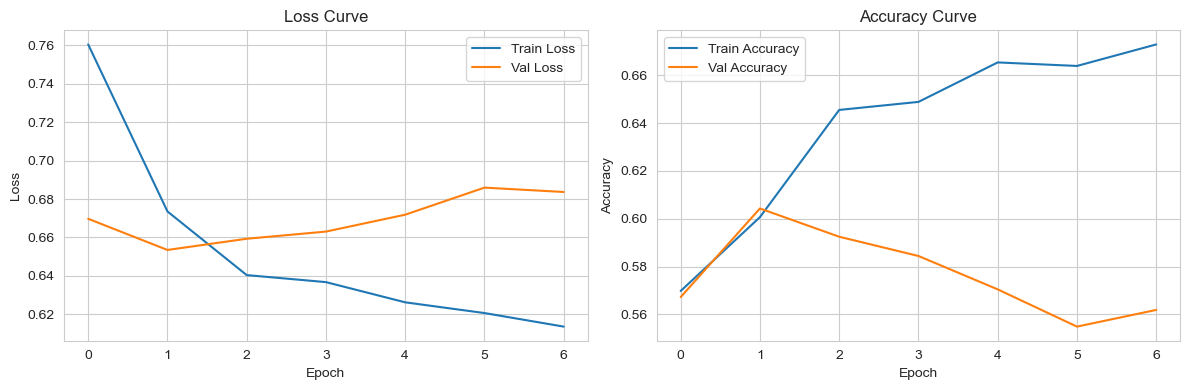

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
y_prob_nn = model.predict(X_test).flatten()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

print('Neural Network Results:')
print(classification_report(y_test, y_pred_nn))
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob_nn), 4))

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Neural Network Results:
              precision    recall  f1-score   support

           0       0.47      0.60      0.53       485
           1       0.67      0.55      0.60       715

    accuracy                           0.57      1200
   macro avg       0.57      0.57      0.57      1200
weighted avg       0.59      0.57      0.57      1200

ROC-AUC: 0.6163


# Part 7 – Model Evaluation

### 7.1 Confusion Matrices (Default Threshold = 0.5)

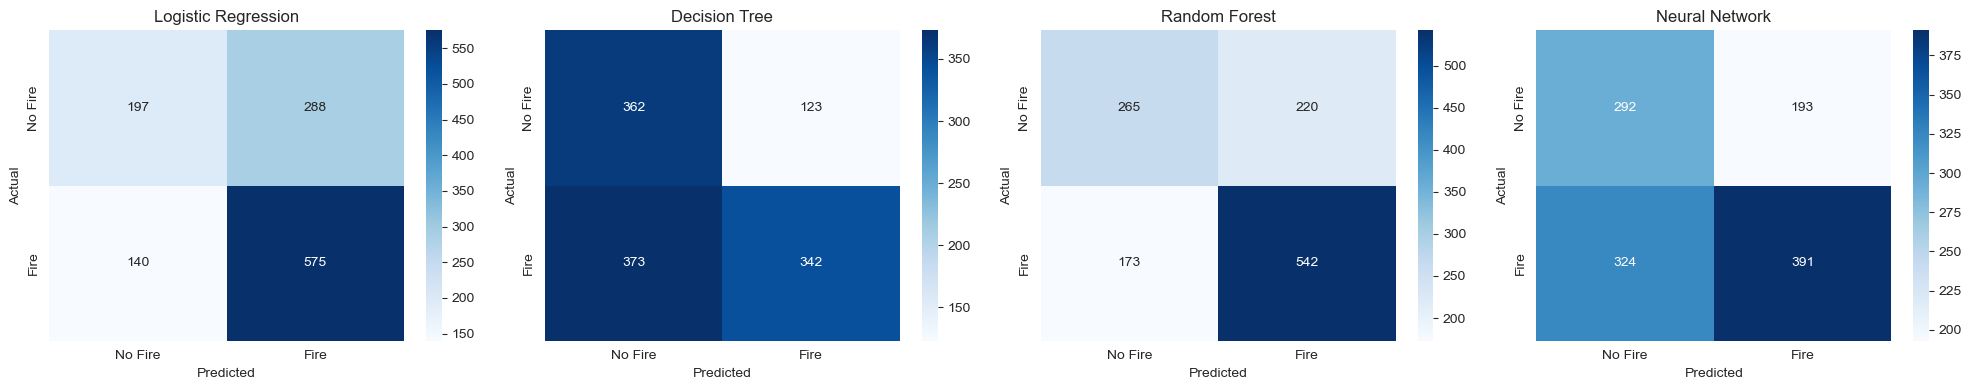

In [ ]:
from sklearn.metrics import confusion_matrix

all_models = [
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree', y_pred_dt),
    ('Random Forest', y_pred_rf),
    ('Neural Network', y_pred_nn)
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for i, (name, pred) in enumerate(all_models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Fire', 'Fire'], yticklabels=['No Fire', 'Fire'])
    axes[i].set_title(name)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

### 7.2 Accuracy, Precision, Recall, F1-Score

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss

all_models_full = [
    ('Logistic Regression', y_pred_lr, y_prob_lr),
    ('Decision Tree', y_pred_dt, y_prob_dt),
    ('Random Forest', y_pred_rf, y_prob_rf),
    ('Neural Network', y_pred_nn, y_prob_nn)
]

for name, pred, prob in all_models_full:
    print(f'--- {name} ---')
    print('Accuracy: ', round(accuracy_score(y_test, pred), 4))
    print('Precision:', round(precision_score(y_test, pred), 4))
    print('Recall:   ', round(recall_score(y_test, pred), 4))
    print('F1-Score: ', round(f1_score(y_test, pred), 4))
    print('Log Loss: ', round(log_loss(y_test, prob), 4))
    print('ROC-AUC:  ', round(roc_auc_score(y_test, prob), 4))
    print()

--- Logistic Regression ---
Accuracy:  0.6433
Precision: 0.6663
Recall:    0.8042
F1-Score:  0.7288
Log Loss:  0.6534
ROC-AUC:   0.647

--- Decision Tree ---
Accuracy:  0.5867
Precision: 0.7355
Recall:    0.4783
F1-Score:  0.5797
Log Loss:  0.7119
ROC-AUC:   0.6325

--- Random Forest ---
Accuracy:  0.6725
Precision: 0.7113
Recall:    0.758
F1-Score:  0.7339
Log Loss:  0.6224
ROC-AUC:   0.7008

--- Neural Network ---
Accuracy:  0.5692
Precision: 0.6695
Recall:    0.5469
F1-Score:  0.602
Log Loss:  0.6839
ROC-AUC:   0.6163



### 7.3 ROC Curves

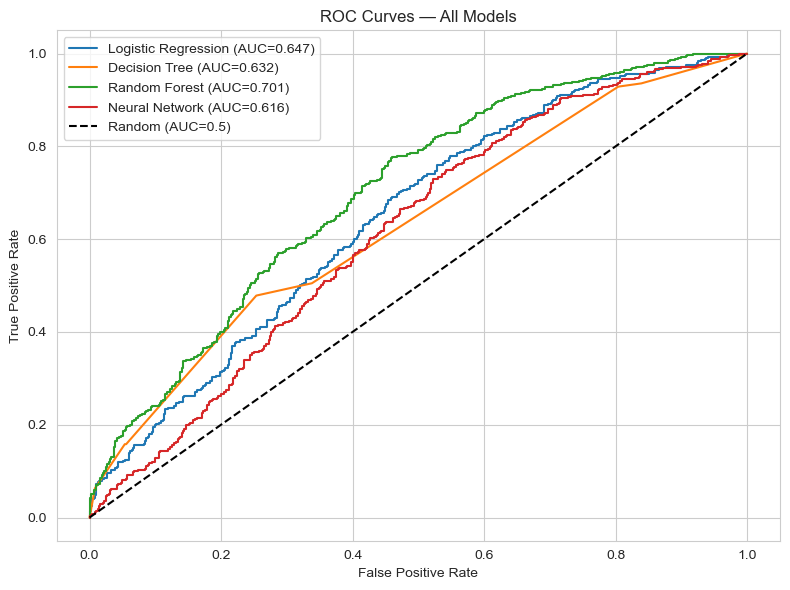

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, prob in [('Logistic Regression', y_prob_lr), ('Decision Tree', y_prob_dt),
                    ('Random Forest', y_prob_rf), ('Neural Network', y_prob_nn)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.tight_layout()
plt.show()

### 7.4 Feature Importance Comparison

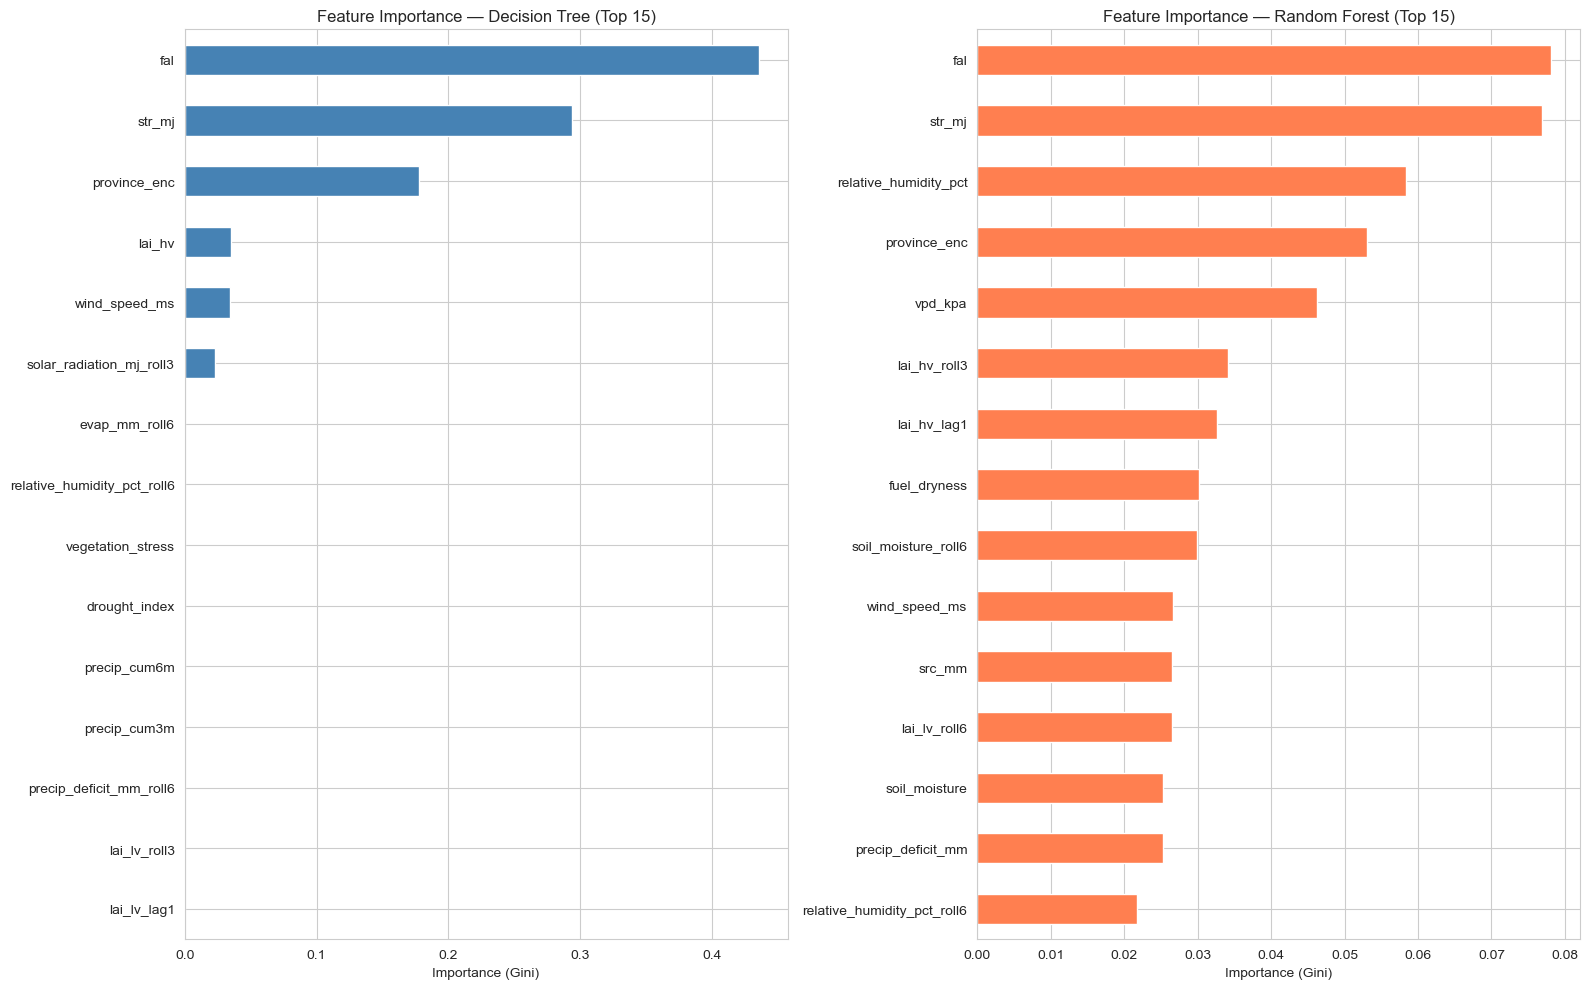

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

imp_dt = pd.Series(dt.feature_importances_, index=features).sort_values(ascending=True).tail(15)
imp_dt.plot(kind='barh', color='steelblue', ax=axes[0])
axes[0].set_title('Feature Importance — Decision Tree (Top 15)')
axes[0].set_xlabel('Importance (Gini)')

imp_rf = pd.Series(rf_best.feature_importances_, index=features).sort_values(ascending=True).tail(15)
imp_rf.plot(kind='barh', color='coral', ax=axes[1])
axes[1].set_title('Feature Importance — Random Forest (Top 15)')
axes[1].set_xlabel('Importance (Gini)')

plt.tight_layout()
plt.show()

### 7.5 Model Comparison Summary

In [ ]:
results = []
for name, pred, prob in all_models_full:
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall': round(recall_score(y_test, pred), 4),
        'F1-Score': round(f1_score(y_test, pred), 4),
        'Log Loss': round(log_loss(y_test, prob), 4),
        'ROC-AUC': round(roc_auc_score(y_test, prob), 4)
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

                     Accuracy  Precision  Recall  F1-Score  Log Loss  ROC-AUC
Model                                                                        
Logistic Regression    0.6433     0.6663  0.8042    0.7288    0.6534   0.6470
Decision Tree          0.5867     0.7355  0.4783    0.5797    0.7119   0.6325
Random Forest          0.6725     0.7113  0.7580    0.7339    0.6224   0.7008
Neural Network         0.5692     0.6695  0.5469    0.6020    0.6839   0.6163


## Part 7.6 – Train vs Validation: Overfitting Check

In [ ]:
y_pred_lr_tr = lr.predict(X_train)
y_prob_lr_tr = lr.predict_proba(X_train)[:, 1]

y_pred_dt_tr = dt.predict(X_train)
y_prob_dt_tr = dt.predict_proba(X_train)[:, 1]

y_pred_rf_tr = rf_best.predict(X_train)
y_prob_rf_tr = rf_best.predict_proba(X_train)[:, 1]

y_prob_nn_tr = model.predict(X_train).flatten()
y_pred_nn_tr = (y_prob_nn_tr >= 0.5).astype(int)

train_preds = [
    ('Logistic Regression', y_pred_lr_tr, y_prob_lr_tr),
    ('Decision Tree',       y_pred_dt_tr, y_prob_dt_tr),
    ('Random Forest',       y_pred_rf_tr, y_prob_rf_tr),
    ('Neural Network',      y_pred_nn_tr, y_prob_nn_tr),
]

rows = []
for (name, pred_tr, prob_tr), (_, pred_va, prob_va) in zip(train_preds, all_models_full):
    rows.append({
        'Model': name,
        'Acc Train':  round(accuracy_score(y_train, pred_tr), 4),
        'Acc Val':    round(accuracy_score(y_test,  pred_va), 4),
        'F1 Train':   round(f1_score(y_train, pred_tr), 4),
        'F1 Val':     round(f1_score(y_test,  pred_va), 4),
        'Prec Train': round(precision_score(y_train, pred_tr), 4),
        'Prec Val':   round(precision_score(y_test,  pred_va), 4),
        'Rec Train':  round(recall_score(y_train, pred_tr), 4),
        'Rec Val':    round(recall_score(y_test,  pred_va), 4),
        'AUC Train':  round(roc_auc_score(y_train, prob_tr), 4),
        'AUC Val':    round(roc_auc_score(y_test,  prob_va), 4),
    })

tv_df = pd.DataFrame(rows).set_index('Model')
print(tv_df.to_string())

291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
                     Acc Train  Acc Val  F1 Train  F1 Val  Prec Train  Prec Val  Rec Train  Rec Val  AUC Train  AUC Val
Model                                                                                                                  
Logistic Regression     0.6796   0.6433    0.7406  0.7288      0.7822    0.6663     0.7031   0.8042     0.7422   0.6470
Decision Tree           0.6960   0.5867    0.7750  0.5797      0.7472    0.7355     0.8049   0.4783     0.6811   0.6325
Random Forest           0.7352   0.6725    0.7994  0.7339      0.7878    0.7113     0.8114   0.7580     0.7906   0.7008
Neural Network          0.6365   0.5692    0.6934  0.6020      0.7679    0.6695     0.6322   0.5469     0.7058   0.6163


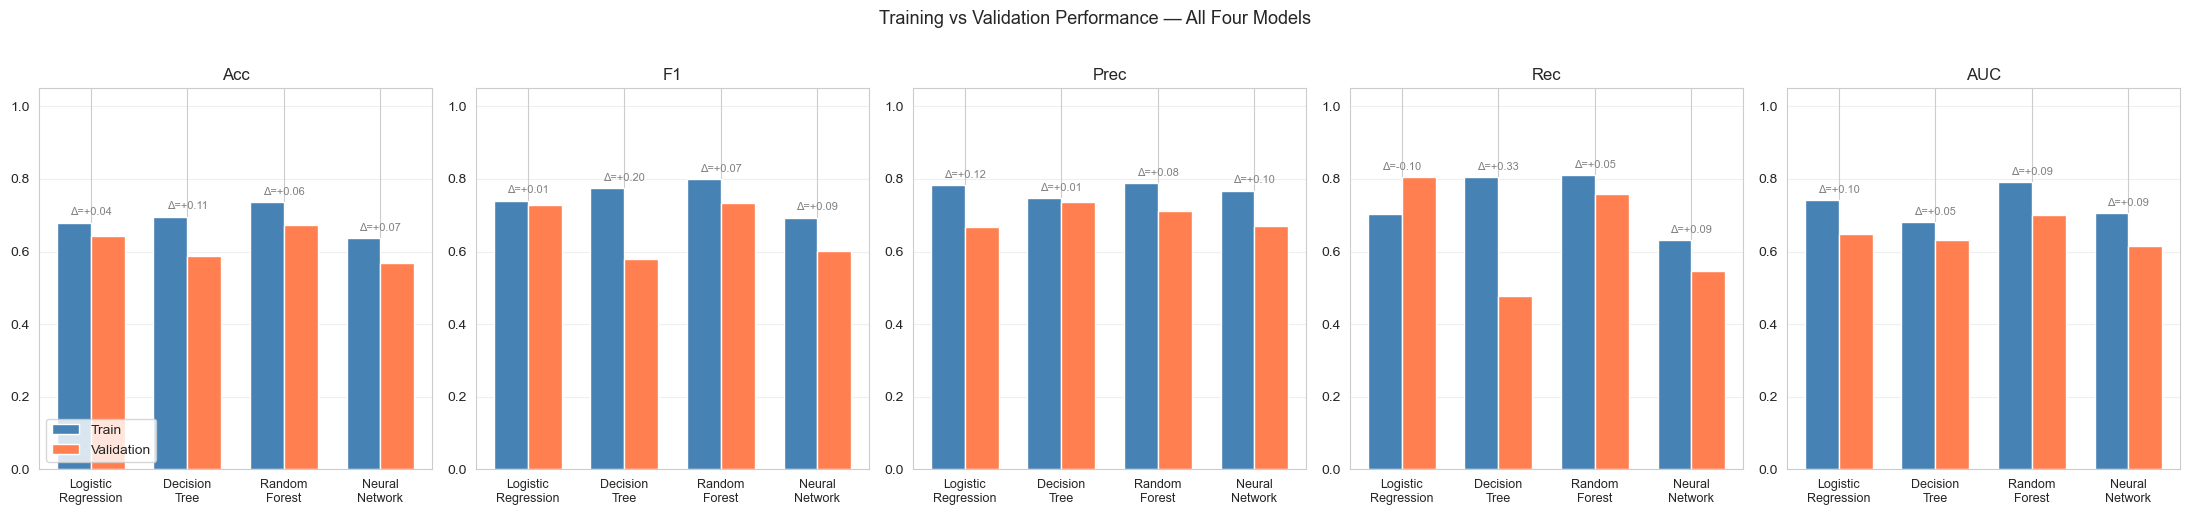

In [ ]:
metrics_to_plot = ['Acc', 'F1', 'Prec', 'Rec', 'AUC']
model_names = tv_df.index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
x = np.arange(len(model_names))
width = 0.35

for ax, metric in zip(axes, metrics_to_plot):
    train_vals = tv_df[f'{metric} Train'].values
    val_vals   = tv_df[f'{metric} Val'].values
    ax.bar(x - width/2, train_vals, width, label='Train', color='steelblue')
    ax.bar(x + width/2, val_vals,   width, label='Validation', color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=9)
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, axis='y')
    for i, (tv, vv) in enumerate(zip(train_vals, val_vals)):
        gap = tv - vv
        ax.text(i, max(tv, vv) + 0.02, f'Δ={gap:+.2f}', ha='center', fontsize=8, color='gray')

axes[0].legend(loc='lower left')
plt.suptitle('Training vs Validation Performance — All Four Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Part 8 – Probability Threshold Tuning

### 8.1 Precision–Recall Trade-off Across Thresholds

 Threshold  Precision  Recall    F1  Flagged
      0.10      0.596   1.000 0.747     1200
      0.15      0.598   1.000 0.748     1196
      0.20      0.605   0.999 0.753     1181
      0.25      0.619   0.990 0.762     1144
      0.30      0.636   0.961 0.765     1081
      0.35      0.655   0.936 0.771     1021
      0.40      0.677   0.906 0.775      957
      0.45      0.686   0.850 0.760      886
      0.50      0.711   0.758 0.734      762
      0.55      0.724   0.617 0.666      609
      0.60      0.747   0.396 0.517      379
      0.65      0.832   0.194 0.315      167
      0.70      0.871   0.076 0.139       62
      0.75      1.000   0.021 0.041       15
      0.80      1.000   0.001 0.003        1
      0.85      0.000   0.000 0.000        0
      0.90      0.000   0.000 0.000        0


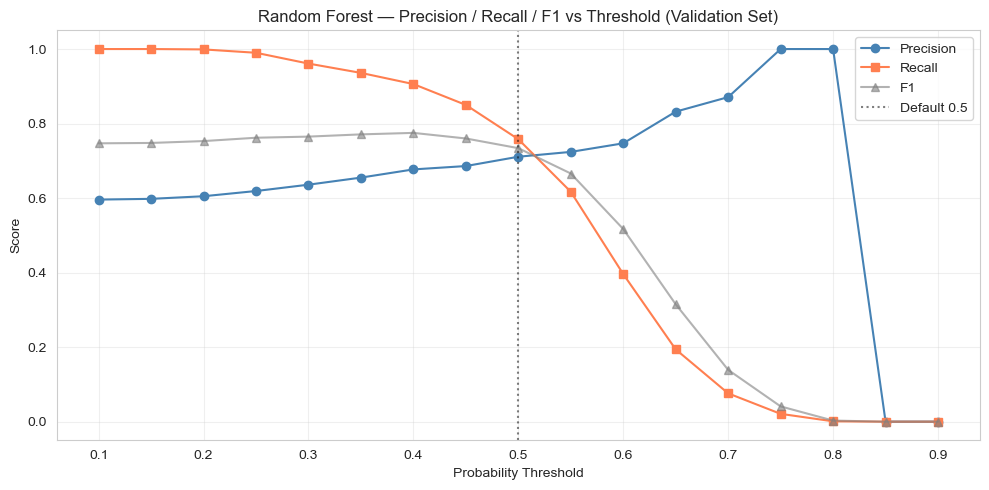

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.91, 0.05)
rows = []
for t in thresholds:
    pred_t = (y_prob_rf >= t).astype(int)
    if pred_t.sum() == 0:
        prec = 0.0
    else:
        prec = precision_score(y_test, pred_t)
    rec  = recall_score(y_test, pred_t)
    f1   = f1_score(y_test, pred_t)
    rows.append({'Threshold': round(t,2), 'Precision': round(prec,3),
                 'Recall': round(rec,3), 'F1': round(f1,3),
                 'Flagged': int(pred_t.sum())})

thr_df = pd.DataFrame(rows)
print(thr_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thr_df['Threshold'], thr_df['Precision'], marker='o', color='steelblue', label='Precision')
ax.plot(thr_df['Threshold'], thr_df['Recall'],    marker='s', color='coral',     label='Recall')
ax.plot(thr_df['Threshold'], thr_df['F1'],        marker='^', color='gray',      label='F1', alpha=0.6)
ax.axvline(0.5, color='k', linestyle=':', alpha=0.5, label='Default 0.5')
ax.set_xlabel('Probability Threshold')
ax.set_ylabel('Score')
ax.set_title('Random Forest — Precision / Recall / F1 vs Threshold (Validation Set)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

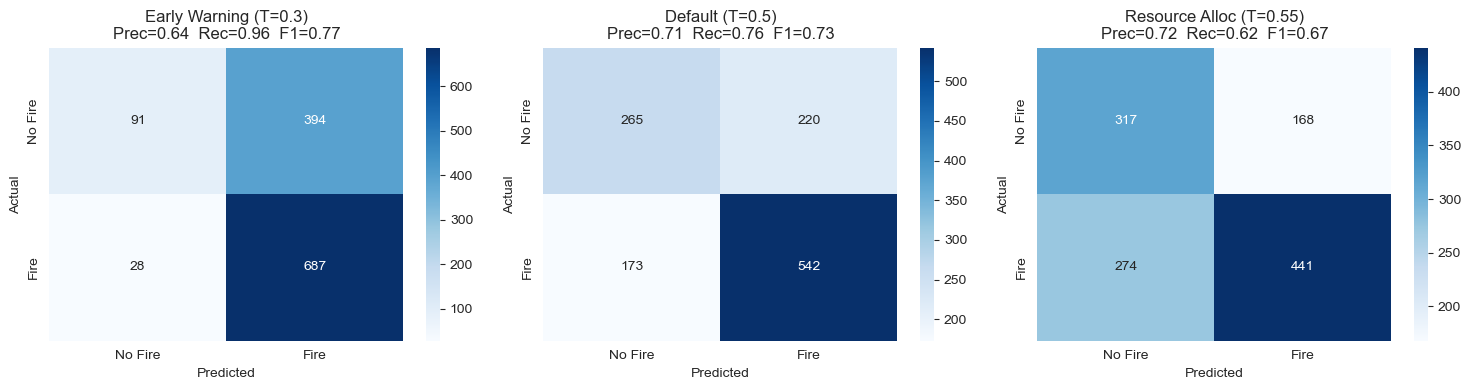

In [ ]:
from sklearn.metrics import confusion_matrix

T_WARNING = 0.30
T_DEFAULT = 0.50
T_ALLOC   = 0.55

labels_thr = [
    (f'Early Warning (T={T_WARNING})', T_WARNING),
    (f'Default (T={T_DEFAULT})',        T_DEFAULT),
    (f'Resource Alloc (T={T_ALLOC})',   T_ALLOC),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, thr) in zip(axes, labels_thr):
    pred_thr = (y_prob_rf >= thr).astype(int)
    cm = confusion_matrix(y_test, pred_thr)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Fire','Fire'], yticklabels=['No Fire','Fire'])
    ax.set_title(f'{name}\nPrec={precision_score(y_test,pred_thr):.2f}  '
                 f'Rec={recall_score(y_test,pred_thr):.2f}  '
                 f'F1={f1_score(y_test,pred_thr):.2f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### 8.3 Calibration Check

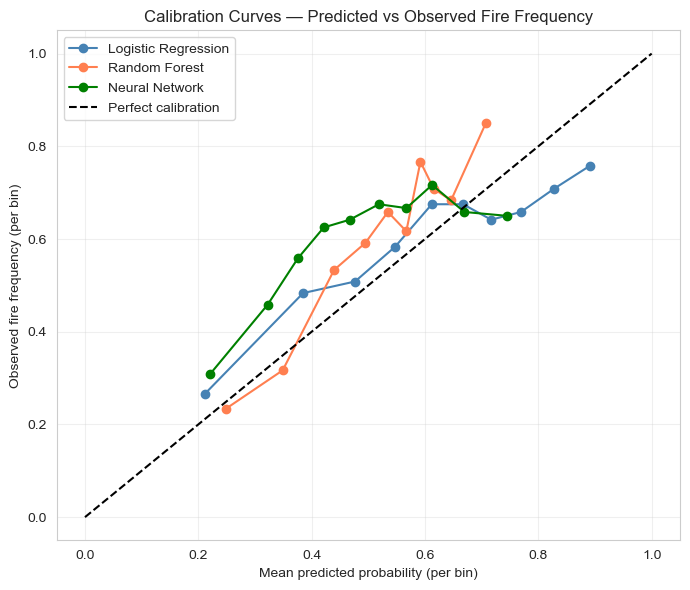

In [ ]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 6))

for name, prob, color in [
    ('Logistic Regression', y_prob_lr, 'steelblue'),
    ('Random Forest',       y_prob_rf, 'coral'),
    ('Neural Network',      y_prob_nn, 'green'),
]:
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=name, color=color)

ax.plot([0,1],[0,1],'k--', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability (per bin)')
ax.set_ylabel('Observed fire frequency (per bin)')
ax.set_title('Calibration Curves — Predicted vs Observed Fire Frequency')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Part 9 – Choropleth Maps: Actual vs Predicted Fire Occurrence

In [ ]:
import geopandas as gpd

provinces_geo = (gpd.read_file(shapefile_path, encoding='utf-8')
                   [['NAME_2','geometry']].to_crs('EPSG:4326')
                   .rename(columns={'NAME_2':'province'}))

val_with_preds = df_val[['province','year','month','fire_binary']].copy()
val_with_preds['pred_rf'] = y_pred_rf
val_with_preds['pred_lr'] = y_pred_lr

def annual_rate(df_year, col):
    return df_year.groupby('province')[col].mean()

maps_2023 = pd.DataFrame({
    'actual':  annual_rate(val_with_preds[val_with_preds['year']==2023], 'fire_binary'),
    'pred_rf': annual_rate(val_with_preds[val_with_preds['year']==2023], 'pred_rf'),
    'pred_lr': annual_rate(val_with_preds[val_with_preds['year']==2023], 'pred_lr'),
})

maps_2024 = pd.DataFrame({
    'actual':  annual_rate(val_with_preds[val_with_preds['year']==2024], 'fire_binary'),
    'pred_rf': annual_rate(val_with_preds[val_with_preds['year']==2024], 'pred_rf'),
    'pred_lr': annual_rate(val_with_preds[val_with_preds['year']==2024], 'pred_lr'),
})

print('2023 sample:')
print(maps_2023.head())
print()
print('2024 sample:')
print(maps_2024.head())

2023 sample:
            actual   pred_rf   pred_lr
province                              
A Coruña  0.583333  0.583333  0.750000
Albacete  0.833333  1.000000  0.916667
Alicante  0.583333  1.000000  0.833333
Almería   0.583333  1.000000  0.416667
Asturias  1.000000  1.000000  1.000000

2024 sample:
            actual  pred_rf   pred_lr
province                             
A Coruña  0.500000      0.5  0.500000
Albacete  1.000000      1.0  1.000000
Alicante  0.916667      1.0  1.000000
Almería   0.750000      1.0  0.750000
Asturias  1.000000      1.0  0.833333


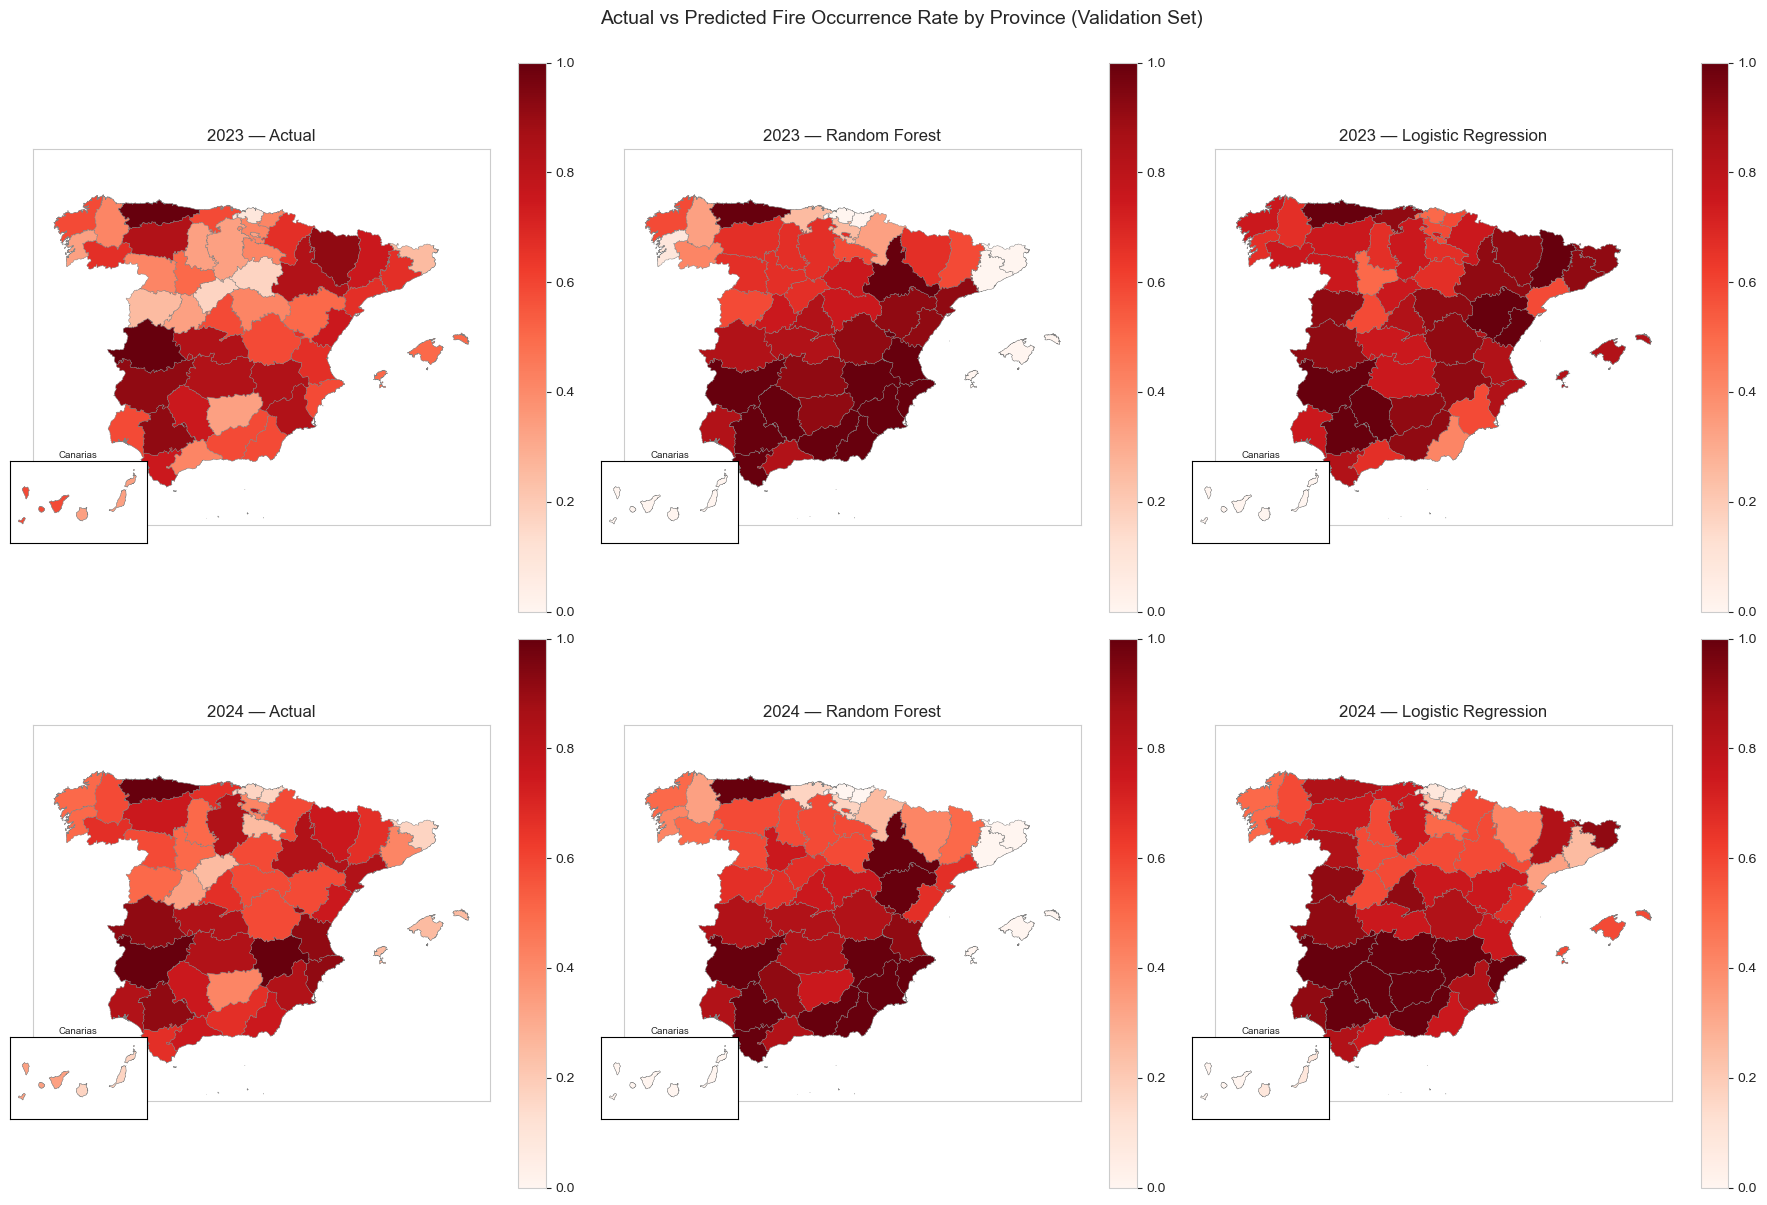

In [ ]:
def plot_map_row(year_data, year_label, fig, row_idx, n_rows):
    cols = [('actual', 'Actual'), ('pred_rf', 'Random Forest'), ('pred_lr', 'Logistic Regression')]
    for col_idx, (key, title) in enumerate(cols):
        ax = fig.add_subplot(n_rows, 3, row_idx*3 + col_idx + 1)
        gdf = provinces_geo.merge(
            year_data[[key]].rename(columns={key:'rate'}).reset_index(),
            on='province', how='left')
        gdf.plot(column='rate', ax=ax, legend=True, cmap='Reds',
                 vmin=0, vmax=1, edgecolor='gray', linewidth=0.3,
                 missing_kwds={'color':'lightgray'})
        ax.set_title(f'{year_label} — {title}', fontsize=12)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlim(-10, 5)
        ax.set_ylim(35, 45)

        inset = ax.inset_axes([-0.05, -0.05, 0.30, 0.22])
        gdf.plot(column='rate', ax=inset, cmap='Reds',
                 vmin=0, vmax=1, edgecolor='gray', linewidth=0.3,
                 missing_kwds={'color':'lightgray'})
        inset.set_xlim(-18.5, -13.0)
        inset.set_ylim(27.0, 29.7)
        inset.set_xticks([]); inset.set_yticks([])
        for spine in inset.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(0.8)
        inset.set_title('Canarias', fontsize=7, pad=2)

fig = plt.figure(figsize=(18, 12))
plot_map_row(maps_2023, '2023', fig, 0, 2)
plot_map_row(maps_2024, '2024', fig, 1, 2)
plt.suptitle('Actual vs Predicted Fire Occurrence Rate by Province (Validation Set)', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

# Part 10 – Province Segmentation (K-Means)

### 10.1 K-Means Clustering on Provinces

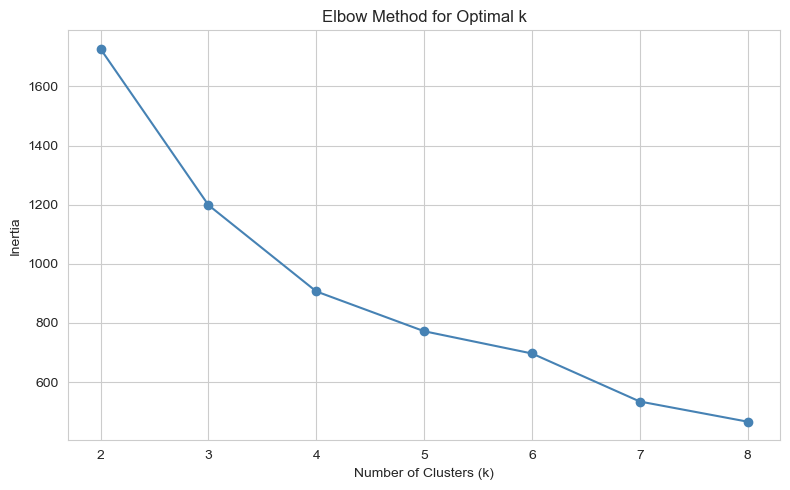

In [ ]:
from sklearn.cluster import KMeans

province_features = df.groupby('province')[features].mean()
scaler_prov = StandardScaler()
X_prov_scaled = scaler_prov.fit_transform(province_features)

inertias = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_prov_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.tight_layout()
plt.show()

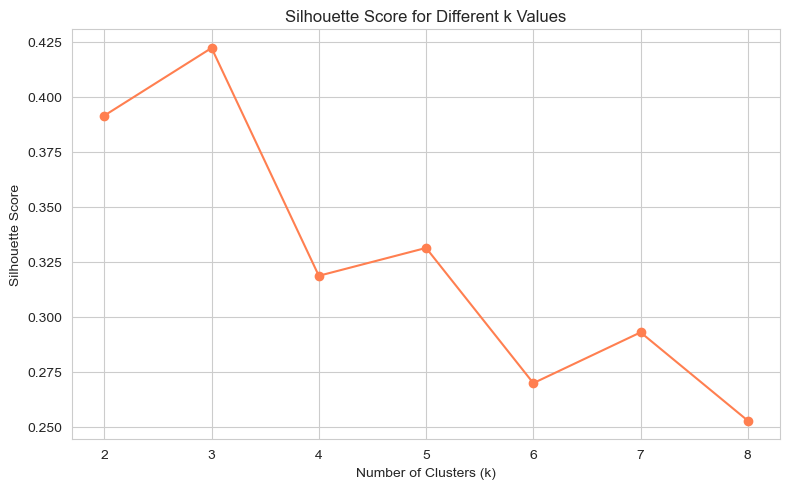

Silhouette scores:
  k=2: 0.3914
  k=3: 0.4222
  k=4: 0.3186
  k=5: 0.3313
  k=6: 0.2698
  k=7: 0.2929
  k=8: 0.2528


In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_prov_scaled)
    sil_scores.append(silhouette_score(X_prov_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(K_range, sil_scores, marker='o', color='coral')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different k Values')
plt.tight_layout()
plt.show()

print('Silhouette scores:')
for k, s in zip(K_range, sil_scores):
    print(f'  k={k}: {round(s, 4)}')

In [ ]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
province_features['Cluster'] = km_final.fit_predict(X_prov_scaled)
print('Cluster distribution:')
print(province_features['Cluster'].value_counts().sort_index())
print()
for c in sorted(province_features['Cluster'].unique()):
    members = province_features[province_features['Cluster'] == c].index.tolist()
    print(f'Cluster {c} ({len(members)} provinces):')
    print('  ' + ', '.join(members))
    print()

Cluster distribution:
Cluster
0    17
1    31
2     2
Name: count, dtype: int64

Cluster 0 (17 provinces):
  A Coruña, Asturias, Barcelona, Burgos, Cantabria, Girona, Guipúzcoa, Huesca, La Rioja, León, Lleida, Lugo, Navarra, Ourense, Pontevedra, Vizcaya, Álava

Cluster 1 (31 provinces):
  Albacete, Alicante, Almería, Badajoz, Baleares, Castellón, Ciudad Real, Cuenca, Cáceres, Cádiz, Córdoba, Granada, Guadalajara, Huelva, Jaén, Madrid, Murcia, Málaga, Palencia, Salamanca, Segovia, Sevilla, Soria, Tarragona, Teruel, Toledo, Valencia, Valladolid, Zamora, Zaragoza, Ávila

Cluster 2 (2 provinces):
  Las Palmas, Santa Cruz de Tenerife



### 10.2 Cluster Profiling

In [ ]:
fire_rate_by_prov = df.groupby('province')['fire_binary'].mean()
province_features['fire_rate'] = fire_rate_by_prov

profile_vars = [v for v in ['temp_c', 'precip_mm', 'relative_humidity_pct', 'soil_moisture', 'vpd_kpa', 'fire_rate']
                if v in province_features.columns]

cluster_profile = province_features.groupby('Cluster')[profile_vars].mean().round(3)
print('Cluster profiles (mean of each climate variable + fire rate):')
print(cluster_profile.to_string())

Cluster profiles (mean of each climate variable + fire rate):
         temp_c  precip_mm  relative_humidity_pct  soil_moisture  vpd_kpa  fire_rate
Cluster                                                                             
0        11.824      2.827              74.719002          0.323    0.396      0.602
1        14.702      1.463              60.925999          0.239    0.807      0.700
2        18.389      0.555              71.889999          0.115    0.600      0.288


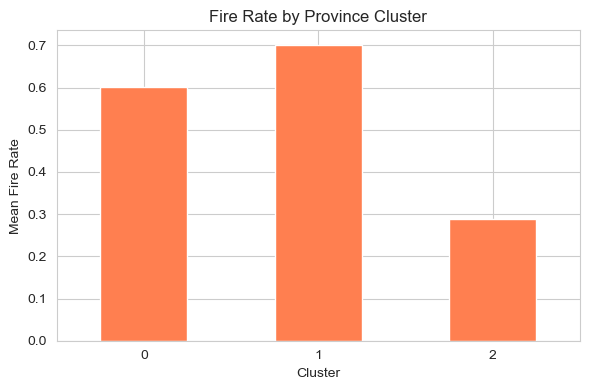

In [ ]:
province_features.groupby('Cluster')['fire_rate'].mean().plot(kind='bar', color='coral', figsize=(6, 4))
plt.title('Fire Rate by Province Cluster')
plt.ylabel('Mean Fire Rate')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 10.3 Cluster Map of Spain

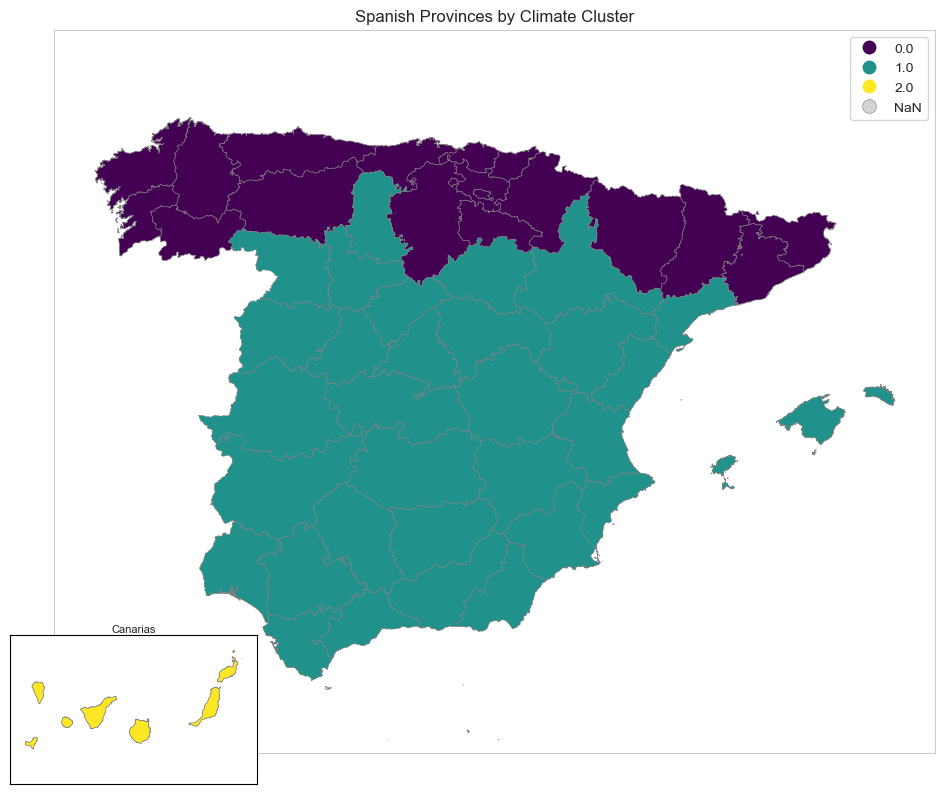

In [ ]:
cluster_map_data = provinces_geo.merge(
    province_features[['Cluster']].reset_index(),
    on='province', how='left')

fig, ax = plt.subplots(figsize=(10, 8))
cluster_map_data.plot(column='Cluster', ax=ax, legend=True, cmap='viridis',
                       edgecolor='gray', linewidth=0.4, categorical=True,
                       missing_kwds={'color':'lightgray'})
ax.set_title('Spanish Provinces by Climate Cluster')
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlim(-10, 5); ax.set_ylim(35, 45)

inset = ax.inset_axes([-0.05, -0.05, 0.28, 0.22])
cluster_map_data.plot(column='Cluster', ax=inset, cmap='viridis',
                       edgecolor='gray', linewidth=0.4, categorical=True,
                       missing_kwds={'color':'lightgray'})
inset.set_xlim(-18.5, -13.0)
inset.set_ylim(27.0, 29.7)
inset.set_xticks([]); inset.set_yticks([])
for spine in inset.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.8)
inset.set_title('Canarias', fontsize=8, pad=2)

plt.tight_layout()
plt.show()

# Part 11 – Data Reduction Analysis (PCA)

### 11.1 PCA — Explained Variance

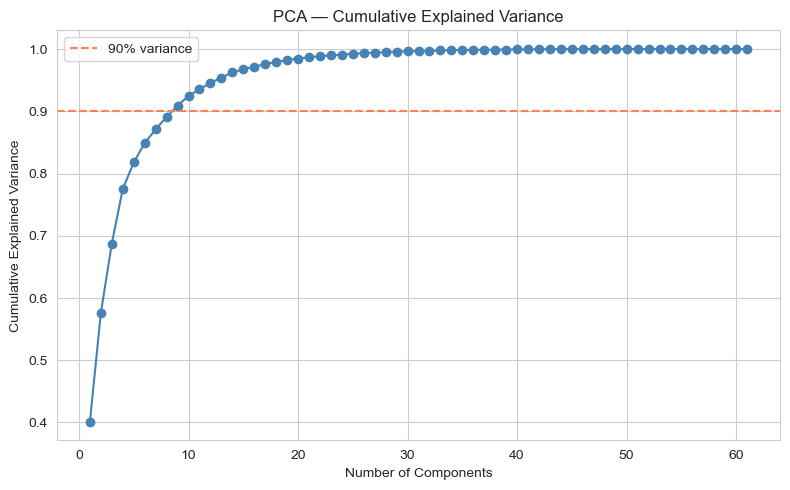

Components needed for 90% variance: 9
Original number of features:        61


In [ ]:
from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(X_train)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', color='steelblue')
plt.axhline(y=0.90, color='coral', linestyle='--', label='90% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

n_components_90 = int(np.argmax(cum_var >= 0.90) + 1)
print(f'Components needed for 90% variance: {n_components_90}')
print(f'Original number of features:        {X_train.shape[1]}')

### 11.2 Re-run Models on PCA Data

In [ ]:
pca = PCA(n_components=n_components_90)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f'PCA reduced features from {X_train.shape[1]} to {X_train_pca.shape[1]}')
print()

lr_pca = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_pca.fit(X_train_pca, y_train)
y_pred_lr_pca = lr_pca.predict(X_test_pca)
y_prob_lr_pca = lr_pca.predict_proba(X_test_pca)[:, 1]

print('Logistic Regression on PCA data:')
print(classification_report(y_test, y_pred_lr_pca))
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob_lr_pca), 4))

PCA reduced features from 61 to 9

Logistic Regression on PCA data:
              precision    recall  f1-score   support

           0       0.51      0.52      0.51       485
           1       0.67      0.67      0.67       715

    accuracy                           0.61      1200
   macro avg       0.59      0.59      0.59      1200
weighted avg       0.61      0.61      0.61      1200

ROC-AUC: 0.6181


In [ ]:
rf_pca = RandomForestClassifier(**rf_grid.best_params_, random_state=42, class_weight='balanced', n_jobs=-1)
rf_pca.fit(X_train_pca, y_train)
y_pred_rf_pca = rf_pca.predict(X_test_pca)
y_prob_rf_pca = rf_pca.predict_proba(X_test_pca)[:, 1]

print('Random Forest on PCA data:')
print('(Note: RF hyperparameters re-used from full-feature GridSearch — not re-tuned for PCA features.)')
print(classification_report(y_test, y_pred_rf_pca))
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob_rf_pca), 4))

Random Forest on PCA data:
(Note: RF hyperparameters re-used from full-feature GridSearch — not re-tuned for PCA features.)
              precision    recall  f1-score   support

           0       0.52      0.54      0.53       485
           1       0.68      0.67      0.67       715

    accuracy                           0.61      1200
   macro avg       0.60      0.60      0.60      1200
weighted avg       0.62      0.61      0.62      1200

ROC-AUC: 0.6395


### 11.3 Performance Comparison — Full vs PCA

In [ ]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Log Loss', 'ROC-AUC'],
    'LR Full': [
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(precision_score(y_test, y_pred_lr), 4),
        round(recall_score(y_test, y_pred_lr), 4),
        round(f1_score(y_test, y_pred_lr), 4),
        round(log_loss(y_test, y_prob_lr), 4),
        round(roc_auc_score(y_test, y_prob_lr), 4),
    ],
    'LR PCA': [
        round(accuracy_score(y_test, y_pred_lr_pca), 4),
        round(precision_score(y_test, y_pred_lr_pca), 4),
        round(recall_score(y_test, y_pred_lr_pca), 4),
        round(f1_score(y_test, y_pred_lr_pca), 4),
        round(log_loss(y_test, y_prob_lr_pca), 4),
        round(roc_auc_score(y_test, y_prob_lr_pca), 4),
    ],
    'RF Full': [
        round(accuracy_score(y_test, y_pred_rf), 4),
        round(precision_score(y_test, y_pred_rf), 4),
        round(recall_score(y_test, y_pred_rf), 4),
        round(f1_score(y_test, y_pred_rf), 4),
        round(log_loss(y_test, y_prob_rf), 4),
        round(roc_auc_score(y_test, y_prob_rf), 4),
    ],
    'RF PCA': [
        round(accuracy_score(y_test, y_pred_rf_pca), 4),
        round(precision_score(y_test, y_pred_rf_pca), 4),
        round(recall_score(y_test, y_pred_rf_pca), 4),
        round(f1_score(y_test, y_pred_rf_pca), 4),
        round(log_loss(y_test, y_prob_rf_pca), 4),
        round(roc_auc_score(y_test, y_prob_rf_pca), 4),
    ]
}).set_index('Metric')

print(comparison.to_string())

           LR Full  LR PCA  RF Full  RF PCA
Metric                                     
Accuracy    0.6433  0.6067   0.6725  0.6150
Precision   0.6663  0.6704   0.7113  0.6810
Recall      0.8042  0.6685   0.7580  0.6657
F1-Score    0.7288  0.6695   0.7339  0.6733
Log Loss    0.6534  0.6696   0.6224  0.6552
ROC-AUC     0.6470  0.6181   0.7008  0.6395


### 11.4 PCA Component Interpretation

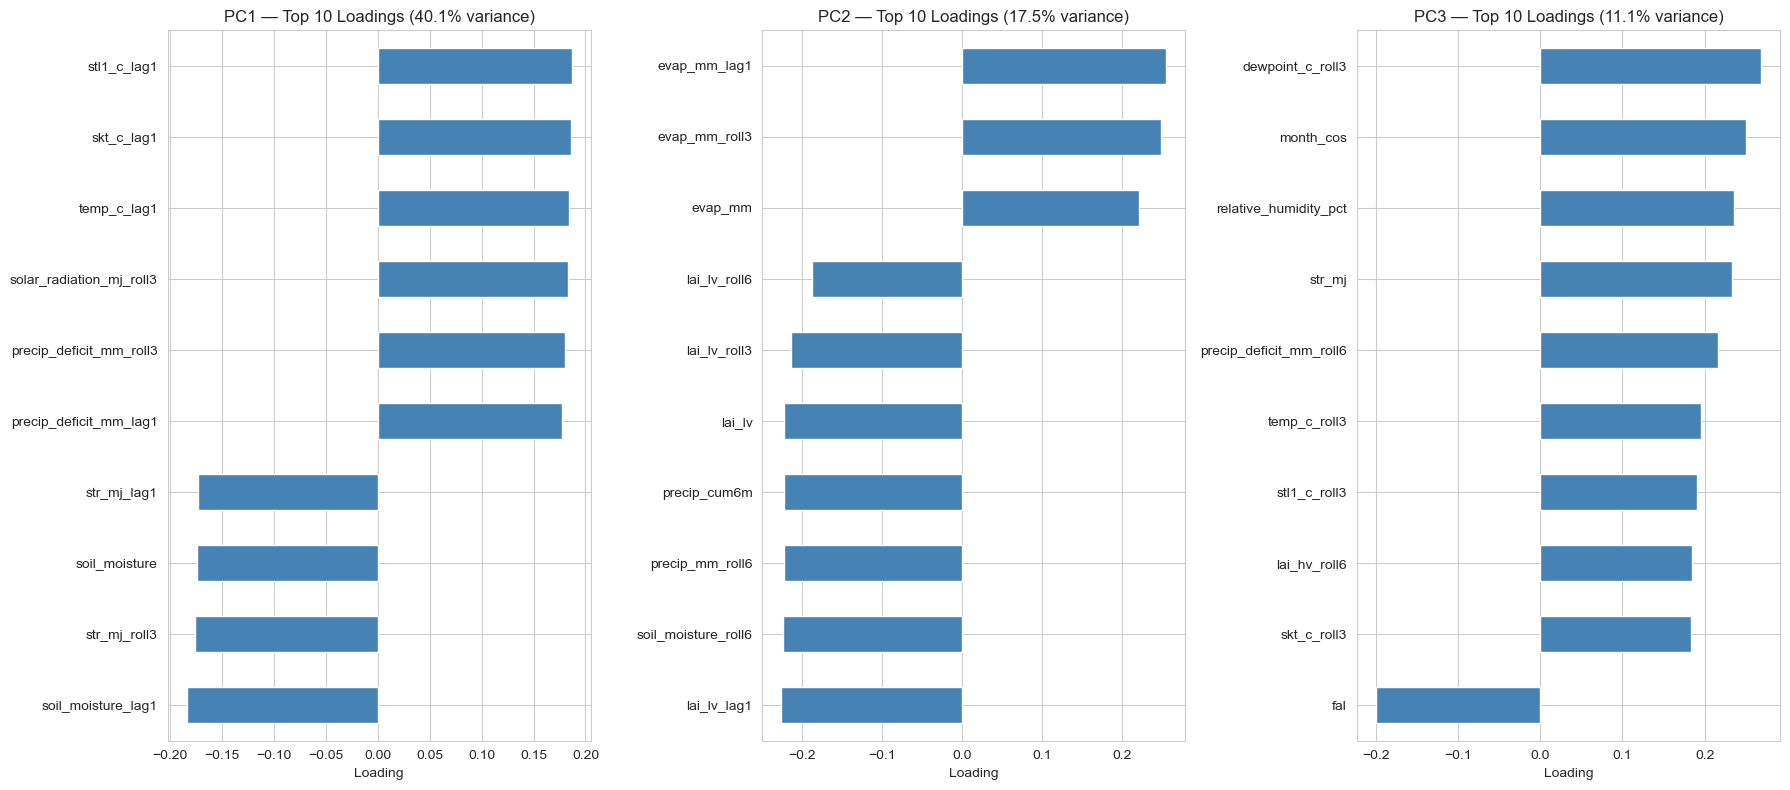

Top 5 features per component:
PC1: ['stl1_c_lag1', 'skt_c_lag1', 'temp_c_lag1', 'soil_moisture_lag1', 'solar_radiation_mj_roll3']
PC2: ['evap_mm_lag1', 'evap_mm_roll3', 'lai_lv_lag1', 'soil_moisture_roll6', 'precip_cum6m']
PC3: ['dewpoint_c_roll3', 'month_cos', 'relative_humidity_pct', 'str_mj', 'precip_deficit_mm_roll6']


In [ ]:
loadings = pd.DataFrame(
    pca.components_[:3].T,
    columns=['PC1', 'PC2', 'PC3'],
    index=features
)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for i, pc in enumerate(['PC1', 'PC2', 'PC3']):
    top10 = loadings[pc].abs().sort_values(ascending=False).head(10).index
    loadings.loc[top10, pc].sort_values().plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f'{pc} — Top 10 Loadings ({pca.explained_variance_ratio_[i]:.1%} variance)')
    axes[i].set_xlabel('Loading')

plt.tight_layout()
plt.show()

print('Top 5 features per component:')
for pc in ['PC1', 'PC2', 'PC3']:
    top = loadings[pc].abs().sort_values(ascending=False).head(5)
    print(f'{pc}: {top.index.tolist()}')